# 24 · 하한으로 학습하기: Jensen 부등식과 ELBO

**이번 질문:** 잠재 $z$를 더해 없애는 합이 너무 크거나(연속이면 적분이라) 아예 계산할 수 없으면, $\log p(x)$ 대신 무엇을 최대화할 수 있을까요?

23번에서는 봉우리가 두 개뿐이라 $p(x)=\sum_z p(z)p(x\mid z)$를 항 두 개로 그냥 더할 수 있었습니다.
잠재가 연속이면 그 합은 적분이 되고, 잠재가 30차원이면 항이 수없이 많아집니다. 계산할 수 없는 값을 최대화할 수는 없습니다.
이 노트북은 그 자리에 **하한** 하나를 놓습니다. 어떤 추측 분포 $q(z)$를 골라도 성립하는 부등식 $\log p(x)\geq\mathrm{ELBO}(q)$를 만들고,
넘치는 양이 정확히 $D_{KL}(q\,\|\,p(z\mid x))$임을 열거 가능한 예에서 **숫자 세 개**로 확인합니다. 그다음 $q$ 자체를 학습시키고, 연속 잠재에서는 재매개화 샘플로 하한을 추정합니다.

- 준비물: [02](../00_기초/02_probability_and_losses.ipynb)의 기댓값·조건부 확률과 softmax, [12](../02_연결/12_gaussian_information.ipynb)의 Gaussian 로그 밀도·KL 닫힌식(5절)·재매개화 미분(6절), [23](23_latent_mixture_em.ipynb)의 혼합 밀도와 책임확률(본문에 짧게 다시 정의합니다), [01](../00_기초/01_gradients_and_learning.ipynb)의 중심차분.
- 도착점: $\log p(x)=\mathrm{ELBO}+\mathrm{KL}$을 열거 가능한 예에서 숫자로 확인하고, 연속 잠재의 Gaussian $q$로 ELBO를 재매개화 샘플로 추정·미분해 정확한 사후확률에 수렴시킵니다.
- 다음 연결: [25 VAE](25_vae.ipynb)는 이 $q$를 신경망(encoder)이 관측마다 만들어 주게 바꿉니다.

### 읽는 법

| 표시 | 뜻 | 어떻게 읽나 |
|---|---|---|
| 🔑 **핵심** | 수식·규칙·코드. 이 노트북이 가르치려는 것 | 남에게 설명할 수 있을 때까지 읽고, 코드를 가리고 다시 써 봅니다 |
| 🔍 **확인** | 검산 결과와 그림의 해석 | 실행해서 눈으로 보고 넘어갑니다. 외울 것은 없습니다 |
| 📎 **참고** | 배경 지식, 환경, 용어의 유래 | 처음 읽을 때는 건너뛰어도 됩니다 |
| ✏️ **연습** | 직접 바꿔 보는 문제 | 손으로 먼저 예상한 뒤 실행합니다 |

새 용어는 처음 나오는 자리에서 **용어** 상자로 한 줄씩 풀이합니다.

**이 노트북에서 반드시 가져갈 세 가지**

1. 어떤 $q(z)$를 골라도 $\log p(x)=\mathrm{ELBO}(q)+D_{KL}(q\,\|\,p(z\mid x))$입니다. KL이 0 이상이라 ELBO는 **하한**이고, $q$가 정확한 사후확률일 때만 등호입니다. `elbo_discrete(x, q) + posterior_kl(x, q) == evidence(x)`.
2. 같은 ELBO를 **재구성 항 − KL 항**으로도 씁니다. $\mathrm{ELBO}(q)=\mathbb E_q[\log p(x\mid z)]-D_{KL}(q\,\|\,p(z))$이고, 25번 VAE의 손실이 바로 이 형태입니다. `recon - kl`.
3. 잠재가 연속이면 KL은 닫힌식으로, 재구성 항은 **재매개화 샘플 평균**으로 계산하고 잡음 $\epsilon$을 고정한 채 미분합니다. `z = mu[:, None] + np.exp(0.5 * logvar)[:, None] * eps`.

| 기호 | shape | 의미 |
|---|---|---|
| $x$ | $(N,)$ | 관측 $N$개 |
| $q$ | $(N,K)$ | 이산 잠재의 추측 분포. 행마다 합이 1 |
| $\varphi$ | $(N,K)$ | $q=\mathrm{softmax}(\varphi)$의 logit |
| $\mu,\ell$ | $(N,)$ | 연속 잠재 $q=\mathcal N(\mu,e^{\ell})$의 평균과 로그 분산 |
| $\epsilon$ | $(N,K)$ | 재매개화에 쓰는 고정된 표준정규 잡음 $K$개. 여기의 $K$는 성분 수가 아니라 **샘플 수**입니다(5절) |

로그의 밑은 $e$이며 정보량의 단위는 nat입니다.

[전체 학습 경로](../../docs/CURRICULUM.md) · [글 규칙](../../docs/WRITING.md) · [그림 설계](../../docs/DESIGN.md) · [그림 보조 코드](../../src/utils/elbo_plots.py)

In [1]:
# 준비 셀: 실행만 하고 넘어가도 됩니다.
# 1) 프로젝트 루트를 import 경로에 넣습니다. 노트북을 어느 폴더에서 열어도 src/를 찾기 위해서입니다.
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src/utils/plotting.py').is_file())   # 현재 폴더부터 위로 올라가며 src/utils/plotting.py가 있는 첫 폴더
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# 2) NumPy, 수치미분 도우미(01번 3절의 중심차분 numerical_gradient와 상대오차 rel_error), 연습 검사 도우미, 이 노트북의 그림 함수(src/utils/elbo_plots.py)
import numpy as np
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils import run_check
from src.utils.elbo_plots import (
    plot_jensen_chord, plot_elbo_gap, plot_two_terms, plot_phi_ascent,
    plot_gaussian_elbo_landscape, plot_elbo_sample_spread, plot_gaussian_q_learning,
    plot_posterior_variants,
)

# 3) 그림 설정. 배열 출력은 소수 6자리로 줄여 읽기 쉽게 합니다.
setup_plots()
np.set_printoptions(precision=6, suppress=True)
print("NumPy", np.__version__, "· Jensen 부등식·ELBO 준비 완료")

NumPy 2.4.6 · Jensen 부등식·ELBO 준비 완료


### 📎 이 노트북의 예시: 두 봉우리 혼합(이산 잠재)과 선형 Gaussian 모형(연속 잠재)

- **두 봉우리 혼합.** 23번과 같은 비율 $\pi=(0.3,0.7)$, 평균 $\mu=(-2,2)$, 표준편차 $\sigma=(0.5,1)$입니다. 잠재 $z$가 0 또는 1뿐이라 **모든 경우를 다 더할 수 있고**, 그래서 증거·하한·KL 세 숫자를 정확히 비교할 수 있습니다. 이 노트북에서 하한의 정답지 역할을 합니다.
- **선형 Gaussian 모형.** $p(z)=\mathcal N(0,1)$에서 $z$를 뽑고 $p(x\mid z)=\mathcal N(az,s^2)$로 $x$를 만듭니다($a=2$, $s=0.5$). 잠재가 **연속**이라 더해서 없앨 수 없지만, 이 모형만은 사후확률 $p(z\mid x)=\mathcal N(m,v)$가 닫힌식이라 학습된 $q$와 대조할 수 있습니다.
- MNIST는 쓰지 않습니다. 이 노트북의 주제는 "무엇을 최대화하는가"라는 목적의 문제이고, 관측이 이미지인지 숫자 하나인지는 식을 바꾸지 않기 때문입니다. 25번에서 encoder가 관측마다 $q$를 만들어 줄 때 MNIST로 돌아옵니다.

> **용어**
>
> - **잠재변수(latent variable)** $z$: 데이터를 만들 때 먼저 정해졌지만 관측에는 적혀 있지 않은 값. 이산 예에서는 "어느 봉우리"(0 또는 1), 연속 예에서는 실수 하나입니다.
> - **닫힌식(closed form)**: 적분이나 샘플 없이 파라미터만으로 바로 쓸 수 있는 식(12번 5절). 이 노트북의 두 예는 모두 닫힌식 정답이 있어서 근사의 오차를 잴 수 있습니다.

아래 네 개의 코드 셀(혼합·선형 Gaussian 상수, 23번 함수 두 셀, 그 검산)은 실행만 하고 넘어가도 됩니다. 두 번에 나누어 공부해도 됩니다. 먼저 1–3절의 부등식과 두 항을 보고, 다음에 4–5절의 학습과 연속 잠재를 진행하세요.

In [2]:
MIX_PI = np.array([0.3, 0.7])                    # (2,): 성분 비율 π_k. 더하면 1 (23번과 같은 값)
MIX_MU = np.array([-2.0, 2.0])                   # (2,): 성분 평균 μ_k
MIX_SIGMA = np.array([0.5, 1.0])                 # (2,): 성분 표준편차 σ_k
LG_A = 2.0                                       # 선형 Gaussian 모형의 기울기 a: p(x | z) = N(a z, s²)
LG_S = 0.5                                       # 같은 모형의 관측 잡음 표준편차 s
print("혼합 π, μ, σ:", MIX_PI, MIX_MU, MIX_SIGMA, "· 선형 Gaussian a, s:", LG_A, LG_S)

혼합 π, μ, σ: [0.3 0.7] [-2.  2.] [0.5 1. ] · 선형 Gaussian a, s: 2.0 0.5


📎 **참고** · 23번에서 만든 함수 다섯 개를 여기서 짧게 다시 정의합니다. 노트북은 저마다 혼자 실행되어야 하기 때문입니다. 유도와 그림은 [23번 1·2절](23_latent_mixture_em.ipynb)에 있습니다.

- `component_log_terms`: 성분마다 $\log\pi_k+\log\mathcal N(x;\mu_k,\sigma_k^2)$ (23번 1절)
- `logsumexp_rows`: 행마다 $\log\sum_k e^{t_k}$를 최댓값을 빼고 계산 (23번 1절)
- `softmax_rows`: 행마다 $e^{t_k}/\sum_j e^{t_j}$ (23번 2절)
- `mix_logpdf`: 위 두 함수를 이 노트북의 혼합 상수에 적용한 $\log p(x)$ (23번 1절)
- `mix_responsibility`: 같은 상수에 softmax를 적용한 책임확률 $r_k(x)$ (23번 2절)

> **코드**
>
> - `x[:, None]`: `(N,)`을 `(N, 1)`로 세워 `(K,)`짜리 성분 배열과 브로드캐스팅합니다. 결과는 `(N, K)` = 점마다 성분 $K$개입니다(00b 3절).
> - `terms.max(axis=1, keepdims=True)`: 행마다 최댓값을 `(N, 1)`로 남겨 빼기 쉽게 합니다. `keepdims`가 없으면 `(N,)`이 되어 축이 어긋납니다.

In [3]:
def component_log_terms(x, pi, mu, sigma):
    """성분마다 log π_k + log N(x; μ_k, σ_k²) (23번 1절). x: (N,), pi·mu·sigma: (K,) → (N, K)."""
    variance = sigma ** 2                                            # (K,): σ_k²
    return np.log(pi) - 0.5 * (np.log(2 * np.pi * variance) + (x[:, None] - mu) ** 2 / variance)


def logsumexp_rows(terms):
    """행마다 log Σ_k exp(t_nk). 최댓값을 빼고 계산합니다(23번 1절). terms: (N, K) → (N,)."""
    biggest = terms.max(axis=1, keepdims=True)                       # (N, 1): 행마다 최댓값
    return (biggest + np.log(np.exp(terms - biggest).sum(axis=1, keepdims=True)))[:, 0]


def softmax_rows(terms):
    """행마다 softmax: 최댓값을 뺀 지수를 행 합으로 나눕니다(23번 2절). terms: (N, K) → (N, K), 행 합 1."""
    shifted = np.exp(terms - terms.max(axis=1, keepdims=True))       # (N, K): 최댓값을 빼도 비율은 그대로
    return shifted / shifted.sum(axis=1, keepdims=True)

In [4]:
def mix_logpdf(x):
    """두 봉우리 혼합의 log p(x) (23번 1절). x: (N,) → (N,)."""
    return logsumexp_rows(component_log_terms(x, MIX_PI, MIX_MU, MIX_SIGMA))


def mix_responsibility(x):
    """두 봉우리 혼합의 책임확률 r_k(x) = p(z = k | x) (23번 2절). x: (N,) → (N, 2), 행 합 1."""
    return softmax_rows(component_log_terms(x, MIX_PI, MIX_MU, MIX_SIGMA))

In [5]:
np.testing.assert_allclose(mix_logpdf(np.array([0.0])), [-3.273491], atol=1e-6)                        # 검산: 23번 1절의 손계산 log p(0)
np.testing.assert_allclose(mix_responsibility(np.array([0.0])), [[0.002120, 0.997880]], atol=1e-6)     # 검산: 23번 2절의 손계산 r(0)
np.testing.assert_allclose(mix_responsibility(np.linspace(-6, 6, 25)).sum(axis=1), 1.0)                # 검산: 책임확률의 행 합 = 1
print("23번 함수 재정의 검산 통과 · log p(0) =", round(float(mix_logpdf(np.array([0.0]))[0]), 6))

23번 함수 재정의 검산 통과 · log p(0) = -3.273491


## 🔑 1. 평균을 먼저 취하면 로그가 더 큽니다: Jensen 부등식

**이 절에서 가져갈 것:** $\log$는 오목한 함수라서 **평균의 로그**가 **로그의 평균**보다 크거나 같습니다. $\log\mathbb E[f]\geq\mathbb E[\log f]$이고, 등호는 $f$가 상수일 때만 성립합니다. 뒤 절에서 만드는 하한은 전부 이 한 줄에서 나옵니다.

값 두 개를 놓고 생각합니다. 어떤 물건의 값이 $1$ 아니면 $4$이고 두 경우가 반반이라고 합시다.
"값의 평균에 로그를 씌운 것"과 "로그를 씌운 값의 평균" 중 어느 쪽이 클까요? 앞의 것은 곡선 위의 한 점, 뒤의 것은 두 점을 이은 **현** 위의 한 점입니다.
$\log$ 곡선은 위로 볼록하게 휘어 있으므로 곡선이 언제나 현보다 위에 있습니다.

> **용어**
>
> - **오목 함수(concave function)**: 그래프 위 두 점을 이은 선분(현, chord)이 언제나 그래프 아래에 있는 함수. $\log$, $\sqrt{\ }$가 그렇습니다. 반대는 볼록 함수입니다.
> - **Jensen 부등식(Jensen's inequality)**: 오목 함수 $g$에 대해 $g(\mathbb E[f])\geq\mathbb E[g(f)]$. 평균을 먼저 취하는 쪽이 더 큽니다.
> - **하한(lower bound)**: "이 값보다 작지는 않다"가 보장된 값. 참값을 계산할 수 없을 때, 하한을 대신 크게 만드는 방법을 씁니다.

가중치 $w_k\geq0$, $\sum_k w_k=1$, 값 $f_k>0$에 대해 **인덱스 식**은

$$\log\Big(\sum_{k=0}^{K-1}w_kf_k\Big)\ \geq\ \sum_{k=0}^{K-1}w_k\log f_k.$$

$w$와 $f$가 둘 다 $(N,K)$면 **배열 식**은 축 1에서 더해 $(N,)$ 두 개를 만드는 것입니다. 축 1이 "경우", 축 0이 "행"입니다.

$$\texttt{log\_of\_mean}=\log\big(\textstyle\sum_k w_{nk}f_{nk}\big),\qquad
\texttt{mean\_of\_log}=\textstyle\sum_k w_{nk}\log f_{nk},\qquad (N,K)\to(N,).$$

등호는 $w_k>0$인 모든 $f_k$가 **같은 값**일 때만 성립합니다. 값이 흩어져 있을수록 두 수의 차이가 커집니다.

**손계산** $f=(1,4)$, $w=(0.5,0.5)$: 평균은 $2.5$이고 $\log 2.5=0.916291$입니다. 로그의 평균은 $\tfrac12(\log 1+\log 4)=\tfrac12\log 4=\log 2=0.693147$입니다.
차이는 $0.916291-0.693147=0.223144$이고, 이것은 정확히 $\log(2.5/2)=\log 1.25$입니다.

In [6]:
# 쓰는 것: (이 셀이 이 절의 계산을 모두 만듭니다)
jensen_values = np.array([1.0, 4.0])                                  # (2,): 값 두 개
jensen_w0 = 0.5                                                       # 손계산에 쓰는 가중치 w_1
jensen_mean = jensen_w0 * jensen_values[1] + (1 - jensen_w0) * jensen_values[0]   # 가중 평균 = 2.5
jensen_log_of_mean = float(np.log(jensen_mean))                       # log E[f]
jensen_mean_of_log = float((1 - jensen_w0) * np.log(jensen_values[0]) + jensen_w0 * np.log(jensen_values[1]))
jensen_t = np.linspace(0.35, 4.6, 400)                                # (400,): log 곡선을 그릴 격자
jensen_w_grid = np.linspace(0.0, 1.0, 201)                            # (201,): 가중치 w_1 을 0에서 1까지
jensen_curve_log_of_mean = np.log((1 - jensen_w_grid) * jensen_values[0] + jensen_w_grid * jensen_values[1])
jensen_curve_mean_of_log = (1 - jensen_w_grid) * np.log(jensen_values[0]) + jensen_w_grid * np.log(jensen_values[1])
print("log E[f] =", round(jensen_log_of_mean, 6), "· E[log f] =", round(jensen_mean_of_log, 6),
      "· 차이 =", round(jensen_log_of_mean - jensen_mean_of_log, 6), "· log 1.25 =", round(float(np.log(1.25)), 6))

log E[f] = 0.916291 · E[log f] = 0.693147 · 차이 = 0.223144 · log 1.25 = 0.223144


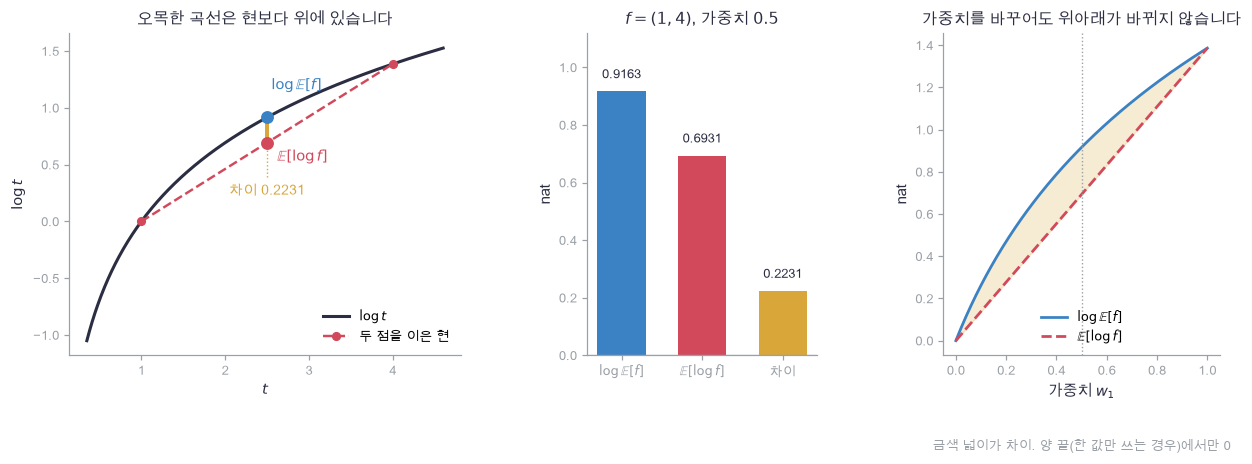

In [7]:
plot_jensen_chord(jensen_t, np.log(jensen_t), jensen_values, jensen_mean,
                  jensen_log_of_mean, jensen_mean_of_log,
                  jensen_w_grid, jensen_curve_log_of_mean, jensen_curve_mean_of_log, jensen_w0)

🔍 **확인** · 왼쪽에서 검은 곡선이 $\log t$이고 빨간 점선이 두 점 $(1,\log 1)$과 $(4,\log 4)$를 이은 현입니다. 가중 평균 $2.5$ 자리에서 곡선 위의 파란 점이 $\log\mathbb E[f]$, 현 위의 빨간 점이 $\mathbb E[\log f]$이고, 금색 막대가 그 차이 $0.2231$입니다.
가운데 막대는 같은 세 숫자입니다. 오른쪽은 가중치 $w_1$을 0에서 1까지 바꾸며 두 값을 함께 그린 것입니다. **파란 곡선이 어디서나 빨간 점선보다 위에** 있고, 금색 넓이가 두 값의 차이입니다.
양 끝($w_1=0$ 또는 $1$)에서만 넓이가 0인데, 그때는 값이 하나뿐이라 "흩어짐"이 없기 때문입니다.

> **코드**
>
> - `rng.gamma(2.0, 1.0, size=(300, 5))`: **양수**만 나오는 난수 `(300, 5)`. 로그를 씌울 값이라 양수여야 합니다.
> - `rng.dirichlet(np.ones(K), size=N)`: 행마다 합이 1인 `(N, K)` 확률 벡터를 무작위로 뽑습니다. "아무 $q$를 넣어도 부등식이 성립하는가"를 300행으로 확인하는 데만 쓰고, 분포 자체는 이 노트북에서 다루지 않습니다.
> - `np.repeat(a, 5, axis=1)`: `(300, 1)` 배열을 옆으로 다섯 번 복사해 `(300, 5)`로 만듭니다. 행마다 값이 모두 같은 경우(등호)를 만들 때 씁니다.

아래 구현은 이 두 값과 그 차이를 $(N,K)$ 배치로 한 번에 냅니다.

In [8]:
def jensen_gap(values, weights):
    """Jensen 부등식의 양변과 그 차이: log Σ_k w_k f_k − Σ_k w_k log f_k ≥ 0.
    values: (N, K) 양수, weights: (N, K) 행 합 1 → (log_of_mean: (N,), mean_of_log: (N,), gap: (N,))."""
    log_of_mean = np.log(np.sum(weights * values, axis=1))           # (N,): 평균을 먼저 취한 뒤 로그
    mean_of_log = np.sum(weights * np.log(values), axis=1)           # (N,): 로그를 먼저 씌운 뒤 평균
    return log_of_mean, mean_of_log, log_of_mean - mean_of_log

In [9]:
# 쓰는 것: jensen_values, jensen_w0, jensen_log_of_mean, jensen_mean_of_log (1절 계산 셀)
hand_log_of_mean, hand_mean_of_log, hand_gap = jensen_gap(jensen_values[None, :], np.array([[1 - jensen_w0, jensen_w0]]))
np.testing.assert_allclose(hand_log_of_mean, [jensen_log_of_mean])                # 검산: 그림의 log E[f]
np.testing.assert_allclose(hand_mean_of_log, [jensen_mean_of_log])                # 검산: 그림의 E[log f]
np.testing.assert_allclose(hand_gap, [np.log(1.25)])                              # 검산: 손계산 차이 = log(2.5/2) = log 1.25
jensen_rng = np.random.default_rng(2401)                                          # 이 절의 검산용 난수 생성기
random_values = jensen_rng.gamma(2.0, 1.0, size=(300, 5)) + 1e-3                   # (300, 5): 양수 값 (0 이 되지 않게 아주 작은 값을 더함)
random_weights = jensen_rng.dirichlet(np.ones(5), size=300)                        # (300, 5): 행 합이 1 인 가중치
_, _, random_gap = jensen_gap(random_values, random_weights)
assert np.all(random_gap >= 0.0), "무작위 양수 값에서도 차이는 언제나 0 이상이어야 합니다"
constant_values = np.repeat(jensen_rng.gamma(2.0, 1.0, size=(300, 1)), 5, axis=1)  # (300, 5): 행마다 같은 값 다섯 개
_, _, constant_gap = jensen_gap(constant_values, random_weights)
assert np.max(np.abs(constant_gap)) < 1e-14, "값이 모두 같으면 차이가 0(등호)이어야 합니다"
print("무작위 300행의 최소 차이:", round(float(random_gap.min()), 8), "· 상수 행의 최대 차이:", float(np.max(np.abs(constant_gap))))

무작위 300행의 최소 차이: 0.00412541 · 상수 행의 최대 차이: 4.440892098500626e-16


### ✏️ 연습 1 · 평균의 로그와 로그의 평균

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.** `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요. 아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

값 `values` `(N, K)`(모두 양수)와 가중치 `weights` `(N, K)`(행 합 1)에서 부등식의 양변을 만듭니다. 왼쪽 `log_of_mean`은 **먼저 가중 평균을 내고 로그**를, 오른쪽 `mean_of_log`는 **먼저 로그를 씌우고 가중 평균**을 냅니다. 두 줄을 채우세요. 검사는 1절 손계산 $f=(1,4)$, $w=(0.5,0.5)$와 값이 모두 같은 행(등호)으로 합니다.

In [10]:
def exercise_jensen_two(values, weights):
    """연습 1: Jensen 부등식의 양변. values: (N, K) 양수, weights: (N, K) 행 합 1 → (log_of_mean: (N,), mean_of_log: (N,))."""
    assert values.shape == weights.shape, "values 와 weights 는 같은 (N, K) 여야 합니다"
    assert np.all(values > 0), "로그를 씌우려면 값이 모두 양수여야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: log_of_mean = log(Σ_k w_k f_k) (모양 (N,)) 과 mean_of_log = Σ_k w_k log f_k (모양 (N,))
    ### 힌트: 둘 다 axis=1 에서 더합니다. 다른 점은 로그를 합의 밖에 씌우느냐 안에 씌우느냐뿐입니다 (1절 수식).
    raise NotImplementedError
    return log_of_mean, mean_of_log

In [11]:
def check_jensen_two(candidate):
    """1절 손계산 f = (1, 4), w = (0.5, 0.5) 와 값이 모두 같은 행으로 검사합니다. 통과하면 메시지를 출력합니다."""
    example_values = np.array([[1.0, 4.0], [2.0, 2.0]])               # (2, 2): 첫 행은 손계산, 둘째 행은 값이 같은 경우
    example_weights = np.array([[0.5, 0.5], [0.3, 0.7]])              # (2, 2): 행 합 1
    log_of_mean, mean_of_log = candidate(example_values, example_weights)
    assert log_of_mean.shape == (2,), f"log_of_mean 의 모양은 (N,) = (2,) 여야 하는데 {log_of_mean.shape} 입니다"
    np.testing.assert_allclose(log_of_mean, [np.log(2.5), np.log(2.0)])          # 검산: 평균 2.5 와 2 의 로그
    np.testing.assert_allclose(mean_of_log, [np.log(2.0), np.log(2.0)])          # 검산: ½(log 1 + log 4) = log 2, 그리고 log 2
    np.testing.assert_allclose(log_of_mean[0] - mean_of_log[0], np.log(1.25))    # 검산: 손계산 차이 = log 1.25
    np.testing.assert_allclose(log_of_mean[1] - mean_of_log[1], 0.0, atol=1e-15)  # 검산: 값이 같으면 등호
    print("Jensen 부등식의 양변: 손계산과 일치합니다.")

run_check(check_jensen_two, exercise_jensen_two, hint="log_of_mean = np.log(np.sum(weights * values, axis=1)) · mean_of_log = np.sum(weights * np.log(values), axis=1)")

☐ exercise_jensen_two: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: log_of_mean = np.log(np.sum(weights * values, axis=1)) · mean_of_log = np.sum(weights * np.log(values), axis=1)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
log_of_mean = np.log(np.sum(weights * values, axis=1))
mean_of_log = np.sum(weights * np.log(values), axis=1)
```

</details>

## 🔑 2. 계산할 수 없는 값 아래에 하한 하나 놓기: ELBO와 세 숫자

**이 절에서 가져갈 것:** 어떤 추측 분포 $q(z)$를 골라도 $\log p(x)=\mathrm{ELBO}(q)+D_{KL}(q\,\|\,p(z\mid x))$입니다. KL은 0 이상이므로 ELBO는 하한이고, **$q$가 정확한 사후확률일 때만** 하한이 증거에 정확히 닿습니다.

23번의 두 봉우리 혼합에서 점 하나 $x=0$을 봅니다. 여기서는 잠재가 0 아니면 1뿐이라 $\log p(0)$을 직접 계산할 수 있었습니다.
계산할 수 없는 상황을 흉내내기 위해, 이번에는 잠재에 대한 **추측 분포** $q$를 하나 들고 와서 그 $q$로만 만들 수 있는 값을 봅니다. 그 값이 참값에서 얼마나 모자라는지가 이 절의 주제입니다.

> **용어**
>
> - **증거(evidence)** $\log p(x)$: 관측만의 로그 밀도. 잠재를 모두 더해(또는 적분해) 없앤 값이라 모델이 이 관측을 얼마나 잘 설명하는지를 나타냅니다.
> - **변분분포(variational distribution)** $q(z)$: 잠재에 대해 우리가 **직접 고르는** 분포. "변분"은 숫자 하나가 아니라 분포(함수) 자체를 고른다는 뜻입니다.
> - **ELBO(evidence lower bound)**: 증거의 하한. $\mathbb E_q[\log p(x,z)-\log q(z)]$이며, 한국어로는 "증거 하한"입니다.
> - **사후확률(posterior)** $p(z\mid x)$: 관측 $x$를 보고 난 뒤의 잠재 분포(23번 2절). 23번의 책임확률 $r_k(x)$가 이산 예의 사후확률이고, 아래에서도 같은 이름으로 부릅니다.
> - **KL 발산(Kullback-Leibler divergence)** $D_{KL}(q\,\|\,p)=\sum_k q_k\log(q_k/p_k)$ (12번 3절): 두 분포가 얼마나 다른지 재는 0 이상의 값. $q=p$일 때만 0입니다.

$\log p(x)=\log\sum_k p(x,z=k)$에 $q_k/q_k$를 끼워 넣으면 가중치가 $q$인 평균의 로그가 되므로 1절의 부등식을 그대로 쓸 수 있습니다.

$$\log p(x)=\log\sum_k q_k\frac{p(x,z=k)}{q_k}\ \geq\ \sum_k q_k\Big[\log p(x,z=k)-\log q_k\Big]=\mathrm{ELBO}(q).$$

넘치는 양도 정확히 적을 수 있습니다. $p(x,z=k)=p(x)\,r_k(x)$(23번 2절의 책임확률)를 대입해 정리하면

$$\log p(x)-\mathrm{ELBO}(q)=\sum_k q_k\log\frac{q_k}{r_k(x)}=D_{KL}\big(q\,\|\,p(z\mid x)\big)\ \geq\ 0.$$

$x$가 $(N,)$이고 $q$가 $(N,K)$면 세 값 모두 $(N,)$입니다. 축 1이 "성분", 축 0이 "관측"입니다. **세 숫자는 언제나 `ELBO + KL = 증거`로 맞물립니다.**

**손계산** $x=0$, $q=(0.5,0.5)$: 결합 로그 항은 $\log p(0,z=0)=-9.429764$, $\log p(0,z=1)=-3.275613$입니다(23번 1절의 두 항에 로그를 씌운 값).
$\log q_k=\log 0.5=-0.693147$이므로 $\mathrm{ELBO}=\tfrac12(-9.429764+0.693147)+\tfrac12(-3.275613+0.693147)=-5.659542$입니다.
$r(0)=(0.002120,0.997880)$이므로 $D_{KL}=0.5\log\frac{0.5}{0.002120}+0.5\log\frac{0.5}{0.997880}=2.386051$입니다. 둘을 더하면 $-3.273491=\log p(0)$입니다.

> **코드**
>
> - `np.column_stack([a, b])`: 길이가 같은 1차원 배열 두 개를 열로 세워 `(N, 2)` 배열을 만듭니다. $q_1$ 격자에서 $q=(1-q_1,\ q_1)$을 만들 때 씁니다.
> - `np.linspace(0.001, 0.999, 999)`: 0과 1을 포함하지 않습니다. $q_k=0$이면 $\log q_k$가 $-\infty$가 되기 때문입니다.

In [12]:
# 쓰는 것: mix_logpdf, mix_responsibility (📎 23번 함수 셀) · component_log_terms, MIX_PI, MIX_MU, MIX_SIGMA (📎 셀)
elbo_x0 = 0.0                                                         # 이 절에서 계속 보는 관측 한 점
q1_grid = np.linspace(0.001, 0.999, 999)                              # (999,): q(z = 1) 을 0 과 1 사이에서
grid_q = np.column_stack([1 - q1_grid, q1_grid])                      # (999, 2): 행 하나가 추측 분포 q
grid_x = np.full(len(q1_grid), elbo_x0)                               # (999,): 같은 관측을 반복
grid_log_joint = component_log_terms(grid_x, MIX_PI, MIX_MU, MIX_SIGMA)   # (999, 2): log p(x, z = k)
elbo_curve = np.sum(grid_q * (grid_log_joint - np.log(grid_q)), axis=1)   # (999,): ELBO(q)
kl_curve = np.sum(grid_q * np.log(grid_q / mix_responsibility(grid_x)), axis=1)   # (999,): 사후확률과의 KL
evidence_at0 = float(mix_logpdf(np.array([elbo_x0]))[0])              # 증거 log p(0)
posterior_at0 = mix_responsibility(np.array([elbo_x0]))[0]            # (2,): 정확한 사후확률 r(0)
hand_elbo = float(elbo_curve[np.argmin(np.abs(q1_grid - 0.5))])       # q = (0.5, 0.5) 자리의 ELBO
hand_kl = float(kl_curve[np.argmin(np.abs(q1_grid - 0.5))])           # 같은 자리의 KL
print("결합 로그 항 log p(0, z = k) =", grid_log_joint[0].round(6))
print(f"ELBO {hand_elbo:.6f} + KL {hand_kl:.6f} = {hand_elbo + hand_kl:.6f} · 증거 {evidence_at0:.6f}")
print("정확한 사후확률 r(0) =", posterior_at0.round(6), "· 곡선의 최댓값 자리 q_1 =", round(float(q1_grid[elbo_curve.argmax()]), 4))

결합 로그 항 log p(0, z = k) = [-9.429764 -3.275613]
ELBO -5.659542 + KL 2.386051 = -3.273491 · 증거 -3.273491
정확한 사후확률 r(0) = [0.00212 0.99788] · 곡선의 최댓값 자리 q_1 = 0.998


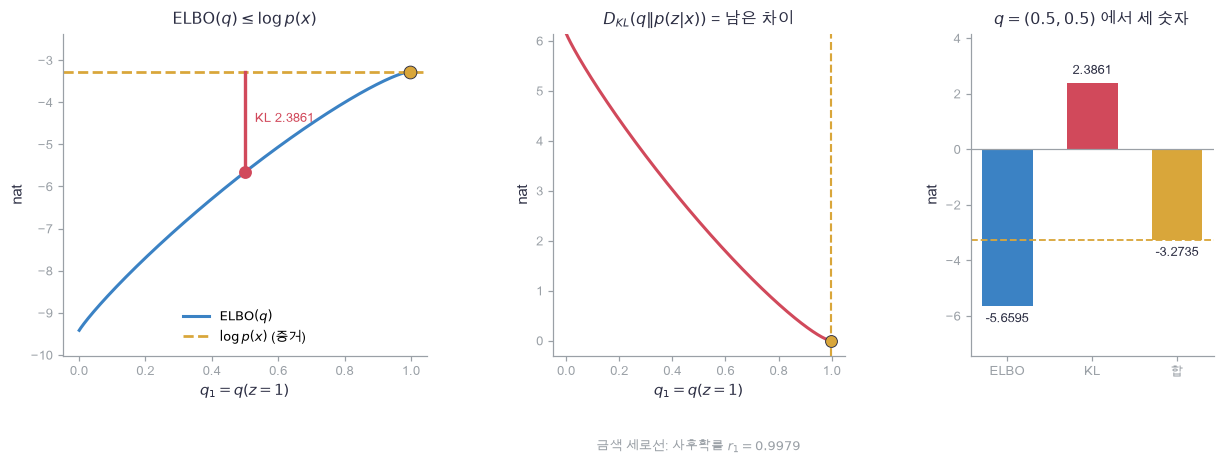

In [13]:
plot_elbo_gap(q1_grid, elbo_curve, kl_curve, evidence_at0, float(posterior_at0[1]), 0.5, hand_elbo, hand_kl)

🔍 **확인** · 왼쪽의 파란 곡선이 $\mathrm{ELBO}(q)$이고 금색 점선이 증거 $\log p(0)=-3.2735$입니다. **곡선은 어디서도 점선을 넘지 않고**, 금색 점 하나에서만 정확히 닿습니다. 그 자리의 $q_1$이 23번에서 구한 책임확률 $r_1(0)=0.9979$입니다.
빨간 세로 막대가 $q=(0.5,0.5)$에서 모자란 양이고, 가운데 그림의 빨간 곡선이 바로 그 양, 곧 $D_{KL}(q\,\|\,p(z\mid0))$입니다. KL은 어디서나 0 이상이고 사후확률에서만 0입니다.
오른쪽 막대 셋이 이 절의 핵심입니다. $\mathrm{ELBO}=-5.6595$, $\mathrm{KL}=2.3861$, 합이 $-3.2735$로 증거와 같습니다.

**하한을 올리는 것은 KL을 줄이는 것과 같은 일입니다.** 증거는 $q$와 무관한 고정된 값이므로, $q$를 바꿔 ELBO를 키우면 그만큼 KL이 줄어듭니다. 이것이 25번 VAE가 하는 일의 전부입니다.

아래 구현은 결합 로그 항을 만드는 함수에서 출발해 증거·하한·KL 세 함수를 따로 둡니다.

In [14]:
# 쓰는 것: MIX_PI, MIX_MU, MIX_SIGMA (📎 혼합 상수 셀) · component_log_terms, logsumexp_rows (📎 23번 함수 셀)
def joint_log_terms(x):
    """결합 로그 밀도 log p(x, z = k) = log π_k + log N(x; μ_k, σ_k²) 를 성분마다.
    ELBO 의 합 안에 들어가는 항입니다. x: (N,) → (N, 2)."""
    return component_log_terms(x, MIX_PI, MIX_MU, MIX_SIGMA)


def evidence(x):
    """증거 log p(x) = log Σ_k p(x, z = k). 잠재를 더해서 없앤 값입니다(23번 1절). x: (N,) → (N,)."""
    return logsumexp_rows(joint_log_terms(x))

In [15]:
# 쓰는 것: mix_responsibility (📎 23번 함수 셀) · joint_log_terms (2절)
def elbo_discrete(x, q):
    """이산 잠재의 ELBO = Σ_k q_k [log p(x, z = k) − log q_k]. x: (N,), q: (N, K) 행 합 1 → (N,)."""
    return np.sum(q * (joint_log_terms(x) - np.log(q)), axis=1)


def posterior_kl(x, q):
    """D_KL(q ‖ p(z | x)) = Σ_k q_k log(q_k / r_k(x)). r 은 23번 2절의 책임확률입니다.
    x: (N,), q: (N, K) 행 합 1 → (N,)."""
    return np.sum(q * np.log(q / mix_responsibility(x)), axis=1)


def elbo_loop(x_value, q_row):
    """검산용 기준 구현: 성분을 하나씩 돌며 더한 ELBO. x_value: 숫자, q_row: (K,) → 숫자 하나."""
    # 쓰는 것: MIX_PI, MIX_MU, MIX_SIGMA (📎 혼합 상수 셀)
    total = 0.0
    for k in range(len(q_row)):
        log_joint = np.log(MIX_PI[k]) - 0.5 * (np.log(2 * np.pi * MIX_SIGMA[k] ** 2) + (x_value - MIX_MU[k]) ** 2 / MIX_SIGMA[k] ** 2)
        total += q_row[k] * (log_joint - np.log(q_row[k]))
    return total

In [16]:
# 쓰는 것: q1_grid, grid_q, grid_x, grid_log_joint, elbo_curve, kl_curve, evidence_at0, hand_elbo (2절 계산 셀) · jensen_gap (1절)
grid_elbo = elbo_discrete(grid_x, grid_q)                             # (999,): 구현으로 다시 계산한 하한
grid_gap = posterior_kl(grid_x, grid_q)                               # (999,): 같은 격자의 KL
identity_error = rel_error(grid_elbo + grid_gap, evidence(grid_x))    # 항등식의 상대오차
assert identity_error < 1e-10, "ELBO + KL 과 증거의 상대오차가 1e−10 아래여야 합니다"
assert np.all(grid_elbo <= evidence(grid_x) + 1e-12), "격자 전체에서 ELBO 는 증거를 넘지 않아야 합니다"
assert np.all(grid_gap >= -1e-12), "KL 은 격자 전체에서 0 이상이어야 합니다"
np.testing.assert_allclose(grid_elbo, elbo_curve)                     # 검산: 위 그림의 ELBO 곡선
np.testing.assert_allclose(grid_gap, kl_curve)                        # 검산: 위 그림의 KL 곡선
np.testing.assert_allclose(elbo_discrete(np.array([0.0]), np.array([[0.5, 0.5]])), [-5.659542], atol=1e-6)   # 검산: 손계산 ELBO
np.testing.assert_allclose(posterior_kl(np.array([0.0]), np.array([[0.5, 0.5]])), [2.386051], atol=1e-6)     # 검산: 손계산 KL
np.testing.assert_allclose(elbo_loop(0.0, np.array([0.5, 0.5])), hand_elbo)    # 검산: 반복문 기준 구현과 같은 값
jensen_f = np.exp(grid_log_joint - np.log(grid_q))                    # (999, 2): 1절의 f_k = p(x, z=k) / q_k
np.testing.assert_allclose(jensen_gap(jensen_f, grid_q)[2], grid_gap, atol=1e-10)   # 검산: 1절의 차이 = 사후확률과의 KL
print(f"항등식 상대오차 {identity_error:.2e} · 하한의 최댓값 {grid_elbo.max():.6f} · 증거 {evidence_at0:.6f}")

항등식 상대오차 8.14e-16 · 하한의 최댓값 -3.273495 · 증거 -3.273491


### ✏️ 연습 2 · 한 줄로 쓰는 이산 ELBO

결합 로그 항 `log_joint` `(N, K)`($=\log p(x,z=k)$)와 추측 분포 `q` `(N, K)`에서 $\mathrm{ELBO}=\sum_k q_k[\log p(x,z=k)-\log q_k]$를 한 줄로 만드세요. 성분 축에서 더하면 관측마다 숫자 하나가 남습니다. 검사는 2절 손계산 $-5.659542$와 격자 전체에서 `elbo_discrete`와 같은지 봅니다.

In [17]:
def exercise_elbo_terms(log_joint, q):
    """연습 2: 이산 잠재의 ELBO. log_joint: (N, K) = log p(x, z=k), q: (N, K) 행 합 1 → (N,)."""
    assert log_joint.shape == q.shape, "log_joint 와 q 는 같은 (N, K) 여야 합니다"
    assert np.all(q > 0), "이 연습은 모든 성분의 확률이 양수인 q 만 다룹니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: elbo = Σ_k q_k [log p(x, z=k) − log q_k]  (모양 (N,))
    ### 힌트: 2절 수식입니다. 괄호 안은 (N, K) 배열이고, 여기에 q 를 곱해 axis=1 에서 더합니다.
    raise NotImplementedError
    return elbo

In [18]:
def check_elbo_terms(candidate):
    """2절 손계산 q = (0.5, 0.5) 와 격자 전체의 elbo_discrete 로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: joint_log_terms, elbo_discrete (2절) · grid_q, grid_x (2절 계산 셀)
    example_q = np.array([[0.5, 0.5]])                                # (1, 2)
    example_log_joint = joint_log_terms(np.array([0.0]))              # (1, 2): x = 0 의 결합 로그 항
    actual = candidate(example_log_joint, example_q)
    assert actual.shape == (1,), f"ELBO 의 모양은 (N,) = (1,) 여야 하는데 {actual.shape} 입니다"
    np.testing.assert_allclose(actual, [-5.659542], atol=1e-6)        # 검산: 2절 손계산
    np.testing.assert_allclose(candidate(joint_log_terms(grid_x), grid_q), elbo_discrete(grid_x, grid_q))   # 검산: 격자 전체
    uniform_q = np.array([[0.25, 0.25, 0.25, 0.25]])                  # (1, 4): 성분 4 개의 균등 분포
    flat_joint = np.zeros((1, 4))                                     # (1, 4): 결합 로그 항이 모두 0
    np.testing.assert_allclose(candidate(flat_joint, uniform_q), [np.log(4.0)])   # 검산: 손계산 −Σ q log q = log 4
    print("이산 ELBO: 손계산·elbo_discrete 와 일치합니다.")

run_check(check_elbo_terms, exercise_elbo_terms, hint="elbo = np.sum(q * (log_joint - np.log(q)), axis=1)")

☐ exercise_elbo_terms: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: elbo = np.sum(q * (log_joint - np.log(q)), axis=1)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
elbo = np.sum(q * (log_joint - np.log(q)), axis=1)
```

</details>

## 🔑 3. 같은 하한을 둘로 쪼개기: 재구성 항 − KL 항

**이 절에서 가져갈 것:** 결합을 $p(x,z)=p(z)p(x\mid z)$로 갈라 넣으면 $\mathrm{ELBO}(q)=\mathbb E_q[\log p(x\mid z)]-D_{KL}(q\,\|\,p(z))$가 됩니다. 앞이 **관측을 얼마나 잘 되살리나**, 뒤가 **추측이 사전분포에서 얼마나 멀어졌나**이고, 25번 VAE의 손실이 정확히 이 형태입니다.

2절의 ELBO는 "결합 로그 밀도 빼기 $\log q$"라는 한 덩어리였습니다. 그런데 모델은 애초에 두 단계로 만들어졌습니다. 먼저 $z$를 $\pi$에서 고르고, 그다음 그 $z$로 $x$를 그립니다.
하한도 그 두 단계에 맞춰 쪼개면 각 항이 무엇을 재는지가 눈에 보입니다.

> **용어**
>
> - **재구성 항(reconstruction term)** $\mathbb E_q[\log p(x\mid z)]$: 추측 분포에서 뽑은 $z$로 관측 $x$를 얼마나 잘 설명하는지. 클수록 좋습니다.
> - **사전분포(prior)** $p(z)$: 관측을 보기 전의 잠재 분포. 여기서는 성분 비율 $\pi$입니다.

$\log p(x,z=k)=\log\pi_k+\log p(x\mid z=k)$를 2절 식에 넣고 항을 나누면 **인덱스 식**은

$$\mathrm{ELBO}(q)=\underbrace{\sum_k q_k\log p(x\mid z=k)}_{\text{재구성 항}}
-\underbrace{\sum_k q_k\log\frac{q_k}{\pi_k}}_{D_{KL}(q\,\|\,p(z))}.$$

**배열 식**으로는 $(N,K)$ 두 판을 각각 축 1에서 더해 $(N,)$ 둘을 만들고 빼는 것입니다. 2절의 KL은 **사후확률**과의 거리였고, 여기의 KL은 **사전분포**와의 거리입니다. 기준이 다르니 값도 다릅니다.

**손계산** $x=0$, $q=(0.5,0.5)$: $\log p(0\mid z=0)=\log\mathcal N(0;-2,0.25)=-8.225791$, $\log p(0\mid z=1)=\log\mathcal N(0;2,1)=-2.918939$이므로 재구성 항은 $\tfrac12(-8.225791-2.918939)=-5.572365$입니다.
$D_{KL}(q\,\|\,\pi)=0.5\log\frac{0.5}{0.3}+0.5\log\frac{0.5}{0.7}=0.087177$입니다. 빼면 $-5.572365-0.087177=-5.659542$로 2절의 ELBO와 같습니다.

> **코드**
>
> - `np.stack([a, b, c])`: 길이가 같은 1차원 배열 셋을 행으로 쌓아 `(3, 2)` 배열을 만듭니다. 비교할 추측 분포 세 개를 한 판에 모을 때 씁니다.
> - `zip(names, recon, kl, elbo)`: 길이가 같은 목록 여러 개를 **나란히** 돌며 한 줄에 하나씩 짝지어 꺼냅니다. `for name, recon, kl, value in zip(...)`이 그 뜻입니다.

In [19]:
# 쓰는 것: MIX_PI, MIX_MU, MIX_SIGMA (📎 혼합 상수 셀) · posterior_at0, evidence_at0 (2절 계산 셀)
term_labels = ["균등\n$q = (0.5,\\ 0.5)$", "사전분포\n$q = \\pi$", "사후확률\n$q = r(0)$"]
term_qs = np.stack([np.array([0.5, 0.5]), MIX_PI, posterior_at0])     # (3, 2): 비교할 추측 분포 세 개
term_x = np.zeros(3)                                                  # (3,): 모두 같은 관측 x = 0
term_conditional = -0.5 * (np.log(2 * np.pi * MIX_SIGMA ** 2) + (term_x[:, None] - MIX_MU) ** 2 / MIX_SIGMA ** 2)   # (3, 2): log p(x | z = k)
term_recon = np.sum(term_qs * term_conditional, axis=1)               # (3,): 재구성 항
term_prior_kl = np.sum(term_qs * np.log(term_qs / MIX_PI), axis=1)    # (3,): 사전분포와의 KL
term_elbo = term_recon - term_prior_kl                                # (3,): 두 항의 차이 = ELBO
print("log p(0 | z = k) =", term_conditional[0].round(6))
for name, recon, kl, value in zip(["균등", "사전분포", "사후확률"], term_recon, term_prior_kl, term_elbo):
    print(f"{name:9s} 재구성 {recon:10.6f} − KL {kl:8.6f} = ELBO {value:10.6f}")

log p(0 | z = k) = [-8.225791 -2.918939]
균등        재구성  -5.572365 − KL 0.087177 = ELBO  -5.659542
사전분포      재구성  -4.510994 − KL 0.000000 = ELBO  -4.510994
사후확률      재구성  -2.930190 − KL 0.343301 = ELBO  -3.273491


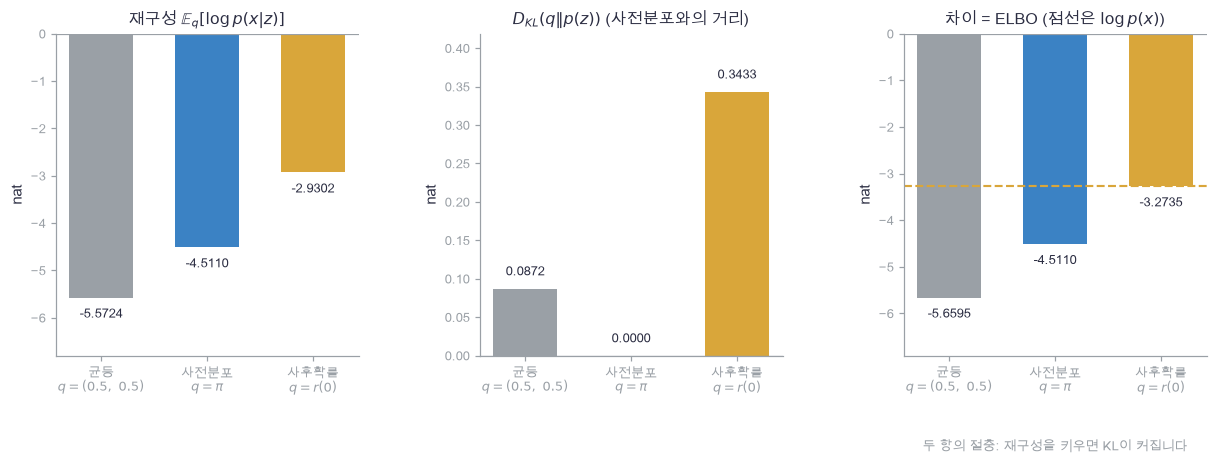

In [20]:
plot_two_terms(term_labels, term_recon, term_prior_kl, term_elbo, evidence_at0)

🔍 **확인** · 왼쪽 막대가 재구성 항입니다. 균등 $q$는 $x=0$에서 거의 불가능한 왼쪽 봉우리에 절반의 무게를 실어 $-5.57$로 가장 나쁘고, 사후확률 $q$는 $-2.93$으로 가장 좋습니다.
가운데 막대는 사전분포와의 KL입니다. $q=\pi$면 정확히 0이고, 사후확률은 사전분포에서 멀어진 대가로 $0.34$를 냅니다.
오른쪽이 그 차이인 ELBO이고, 금색 점선이 증거입니다. **재구성만 키우면 KL이 커지고, KL만 줄이면 재구성이 나빠집니다.** 두 항의 절충이 가장 잘 맞는 자리가 사후확률이고, 그때만 하한이 점선에 닿습니다.

아래 구현은 조건부 로그 밀도와 사전분포 KL을 따로 두고, 둘을 합쳐 2절과 같은 ELBO를 냅니다.

In [21]:
def conditional_log_terms(x):
    """조건부 로그 밀도 log p(x | z = k) = log N(x; μ_k, σ_k²) 를 성분마다. x: (N,) → (N, 2)."""
    # 쓰는 것: MIX_MU, MIX_SIGMA (📎 혼합 상수 셀)
    return -0.5 * (np.log(2 * np.pi * MIX_SIGMA ** 2) + (x[:, None] - MIX_MU) ** 2 / MIX_SIGMA ** 2)


def prior_kl(q):
    """D_KL(q ‖ p(z)) = Σ_k q_k log(q_k / π_k). 사전분포는 성분 비율 π 입니다. q: (N, K) → (N,)."""
    # 쓰는 것: MIX_PI (📎 혼합 상수 셀)
    return np.sum(q * np.log(q / MIX_PI), axis=1)


def elbo_two_terms(x, q):
    """같은 ELBO 를 두 항으로: E_q[log p(x | z)] − D_KL(q ‖ p(z)).
    x: (N,), q: (N, K) 행 합 1 → (recon: (N,), kl: (N,), elbo: (N,))."""
    recon = np.sum(q * conditional_log_terms(x), axis=1)             # (N,): 재구성 항
    kl = prior_kl(q)                                                  # (N,): 사전분포와의 KL
    return recon, kl, recon - kl

In [22]:
# 쓰는 것: term_qs, term_x, term_recon, term_prior_kl (3절 계산 셀) · grid_q, grid_x (2절 계산 셀) · elbo_discrete (2절) · MIX_PI (📎 혼합 상수 셀)
split_recon, split_kl, split_elbo = elbo_two_terms(term_x, term_qs)
np.testing.assert_allclose(split_recon, term_recon)                   # 검산: 위 그림의 재구성 항
np.testing.assert_allclose(split_kl, term_prior_kl)                   # 검산: 위 그림의 사전분포 KL
np.testing.assert_allclose(split_elbo, elbo_discrete(term_x, term_qs))   # 검산: 2절의 한 덩어리 식과 같은 값
np.testing.assert_allclose(elbo_two_terms(grid_x, grid_q)[2], elbo_discrete(grid_x, grid_q))   # 검산: 격자 999 개 전체에서 같음
np.testing.assert_allclose(split_recon[0], -5.572365, atol=1e-6)      # 검산: 손계산 재구성 항
np.testing.assert_allclose(split_kl[0], 0.087177, atol=1e-6)          # 검산: 손계산 D_KL(q ‖ π)
np.testing.assert_allclose(prior_kl(MIX_PI[None, :]), [0.0], atol=1e-15)   # 검산: q = π 면 사전분포 KL 은 0
assert split_recon[2] > split_recon[0], "사후확률의 재구성 항이 균등 q 보다 커야 합니다"
assert split_kl[2] > split_kl[1], "사후확률은 사전분포에서 멀어졌으므로 KL 이 0 보다 커야 합니다"
print("두 항으로 쪼갠 ELBO:", split_elbo.round(6), "· 한 덩어리 식:", elbo_discrete(term_x, term_qs).round(6))

두 항으로 쪼갠 ELBO: [-5.659542 -4.510994 -3.273491] · 한 덩어리 식: [-5.659542 -4.510994 -3.273491]


### ✏️ 연습 3 · 사전분포에서 얼마나 멀어졌나

추측 분포 `q` `(N, K)`와 사전분포 `pi` `(K,)`에서 $D_{KL}(q\,\|\,p(z))=\sum_k q_k\log(q_k/\pi_k)$를 한 줄로 만드세요. 2절의 KL은 사후확률이 기준이었고 이번에는 **사전분포**가 기준입니다. 검사는 3절 손계산 $0.087177$, $q=\pi$인 경우(0), 그리고 `prior_kl`과 같은지 봅니다.

In [23]:
def exercise_prior_kl(q, pi):
    """연습 3: 사전분포와의 KL. q: (N, K) 행 합 1, pi: (K,) → (N,)."""
    assert q.shape[1] == len(pi), "q 의 열 수는 성분 수 K 와 같아야 합니다"
    assert np.all(q > 0), "이 연습은 모든 성분의 확률이 양수인 q 만 다룹니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: kl = Σ_k q_k log(q_k / π_k)  (모양 (N,))
    ### 힌트: 3절 수식입니다. pi 는 (K,) 이고 q 는 (N, K) 라 브로드캐스팅으로 나뉩니다. 더하는 축은 axis=1 입니다.
    raise NotImplementedError
    return kl

In [24]:
def check_prior_kl(candidate):
    """3절 손계산 q = (0.5, 0.5), q = π 와 3절의 prior_kl 로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: prior_kl (3절) · MIX_PI (📎 혼합 상수 셀) · term_qs (3절 계산 셀)
    example_q = np.array([[0.5, 0.5], [0.3, 0.7]])                    # (2, 2): 균등과 사전분포 자신
    actual = candidate(example_q, np.array([0.3, 0.7]))
    assert actual.shape == (2,), f"KL 의 모양은 (N,) = (2,) 여야 하는데 {actual.shape} 입니다"
    np.testing.assert_allclose(actual[0], 0.087177, atol=1e-6)        # 검산: 3절 손계산 0.5 log(0.5/0.3) + 0.5 log(0.5/0.7)
    np.testing.assert_allclose(actual[1], 0.0, atol=1e-15)            # 검산: q = π 면 0
    np.testing.assert_allclose(candidate(term_qs, MIX_PI), prior_kl(term_qs))   # 검산: 3절 prior_kl 과 같음
    hand_other = 0.5 * np.log(2.0) + 0.5 * np.log(2.0 / 3.0)          # 사전분포가 (0.25, 0.75) 일 때의 손계산
    np.testing.assert_allclose(candidate(np.array([[0.5, 0.5]]), np.array([0.25, 0.75])), [hand_other])   # 검산: 손계산 다른 사전분포
    print("사전분포와의 KL: 손계산·prior_kl 과 일치합니다.")

run_check(check_prior_kl, exercise_prior_kl, hint="kl = np.sum(q * np.log(q / pi), axis=1)")

☐ exercise_prior_kl: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: kl = np.sum(q * np.log(q / pi), axis=1)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
kl = np.sum(q * np.log(q / pi), axis=1)
```

</details>

## 🔑 4. $q$를 고르지 말고 학습시키기: logit에 대한 경사 상승

**이 절에서 가져갈 것:** $q=\mathrm{softmax}(\varphi)$로 두면 ELBO의 $\varphi$ 기울기는 $\partial\mathrm{ELBO}/\partial\varphi_j=q_j\big[\log p(x,z=j)-\log q_j-\mathrm{ELBO}\big]$입니다. 이 방향으로 올라가면 $q$는 정확한 사후확률로 수렴하고 기울기는 정확히 0이 됩니다.

2절과 3절에서는 $q$를 사람이 골라서 넣었습니다. 실제로는 어떤 $q$가 좋은지 모릅니다. 그러면 **$q$도 학습시키면 됩니다.**
확률은 0과 1 사이이고 합이 1이어야 하므로 직접 다루기 불편합니다. 02번 8절에서 점수 $K$개를 확률 $K$개로 바꾼 그 방법, softmax를 씁니다. 자유롭게 움직이는 실수 $\varphi$를 두고 $q=\mathrm{softmax}(\varphi)$로 만들면 제약이 저절로 지켜집니다.

> **용어**
>
> - **logit** $\varphi$: softmax에 넣기 전의 점수(02번 8절). 크기가 아니라 **차이**만 확률에 영향을 줍니다.
> - **경사 상승(gradient ascent)**: 최대화하려는 값의 기울기 **방향으로** 한 걸음 가는 것. 01번 6절의 경사하강에서 부호만 바꾼 것입니다.

$q_k=\mathrm{softmax}_k(\varphi)$의 미분은 $\partial q_k/\partial\varphi_j=q_k(\delta_{kj}-q_j)$입니다($\delta_{kj}$는 $k=j$면 1, 아니면 0). $g_k=\log p(x,z=k)-\log q_k$로 두면 $\mathrm{ELBO}=\sum_kq_kg_k$이고,
$\sum_kq_k\,\partial g_k/\partial\varphi_j=-\sum_kq_k(\delta_{kj}-q_j)=0$이라 그 몫이 통째로 사라집니다. 남는 것은

$$\frac{\partial\,\mathrm{ELBO}}{\partial\varphi_j}=q_j\Big[\underbrace{\log p(x,z=j)-\log q_j}_{g_j}-\mathrm{ELBO}(q)\Big],\qquad \varphi:(N,K)\to d\varphi:(N,K).$$

말로 읽으면 "성분 $j$의 몫 $g_j$가 **평균보다 크면** 그 성분의 logit을 올리라"입니다. 모든 $g_j$가 같아지면 기울기가 0입니다.
$g_j=\log p(x,z=j)-\log q_j$가 $j$와 무관해지는 것은 $q_j\propto p(x,z=j)$, 곧 $q$가 정확한 사후확률 $r$일 때뿐이고, 그때 $g_j=\log p(x)$이므로 대괄호가 정확히 0이 됩니다.

📎 기울기의 모든 성분을 더하면 $\sum_jq_j g_j-\mathrm{ELBO}\sum_jq_j=0$입니다. logit은 전체를 같은 값만큼 올려도 확률이 바뀌지 않으므로, 기울기가 그 방향으로는 움직이지 않는 것이 자연스럽습니다.

이번 절은 관측을 $x=-1$로 바꿉니다. $x=0$에서는 정답이 $(0.002,\,0.998)$로 너무 한쪽이라 $q$가 움직이는 모습이 잘 보이지 않기 때문입니다. $x=-1$에서는 두 봉우리가 $91$ 대 $9$로 겨룹니다.

> **코드** · `phi + learning_rate * dphi`: 더하기입니다. 손실을 줄이는 것이 아니라 하한을 **키우는** 것이라 부호가 경사하강과 반대입니다.

In [25]:
# 쓰는 것: q1_grid, grid_q (2절 계산 셀) · component_log_terms, softmax_rows, mix_responsibility, mix_logpdf (📎 23번 함수 셀)
# 쓰는 것: MIX_PI, MIX_MU, MIX_SIGMA (📎 혼합 상수 셀)
ascent_x0 = -1.0                                                      # 이 절에서 보는 관측. 두 봉우리가 91 대 9 로 겨루는 자리
ascent_grid_x = np.full(len(q1_grid), ascent_x0)                      # (999,): 같은 관측을 반복
ascent_log_joint = component_log_terms(ascent_grid_x, MIX_PI, MIX_MU, MIX_SIGMA)   # (999, 2): log p(x, z = k)
ascent_curve = np.sum(grid_q * (ascent_log_joint - np.log(grid_q)), axis=1)         # (999,): ELBO(q)
ascent_grad_curve = q1_grid * (ascent_log_joint[:, 1] - np.log(q1_grid) - ascent_curve)   # (999,): 격자에서 본 ∂ELBO/∂φ_1
ascent_r = mix_responsibility(np.array([ascent_x0]))[0]               # (2,): 정확한 사후확률 r(−1)
ascent_evidence = float(mix_logpdf(np.array([ascent_x0]))[0])         # 증거 log p(−1)
ascent_phi = np.zeros((1, 2))                                         # (1, 2): 시작 logit. softmax 하면 q = (0.5, 0.5)
ascent_x = np.array([ascent_x0])                                      # (1,)
ascent_q1, ascent_elbo, ascent_kl = [], [], []                        # 스텝마다 기록할 세 가지
for step in range(61):
    q_now = softmax_rows(ascent_phi)                                  # (1, 2): 지금의 추측 분포
    log_joint_now = component_log_terms(ascent_x, MIX_PI, MIX_MU, MIX_SIGMA)   # (1, 2)
    elbo_now = np.sum(q_now * (log_joint_now - np.log(q_now)), axis=1)         # (1,)
    ascent_q1.append(float(q_now[0, 1]))
    ascent_elbo.append(float(elbo_now[0]))
    ascent_kl.append(float(np.sum(q_now * np.log(q_now / ascent_r), axis=1)[0]))
    ascent_phi = ascent_phi + 1.0 * q_now * (log_joint_now - np.log(q_now) - elbo_now[:, None])   # 경사 상승 한 걸음
print(f"시작 q_1 {ascent_q1[0]:.6f} → 끝 q_1 {ascent_q1[-1]:.6f} · 정확한 r_1 {ascent_r[1]:.6f}")
print(f"시작 ELBO {ascent_elbo[0]:.6f} → 끝 ELBO {ascent_elbo[-1]:.6f} · 증거 {ascent_evidence:.6f}")
print(f"KL: 시작 {ascent_kl[0]:.6f} → 5스텝 뒤 {ascent_kl[5]:.2e} → 끝 {ascent_kl[-1]:.2e}")

시작 q_1 0.500000 → 끝 q_1 0.087398 · 정확한 r_1 0.087396
시작 ELBO -3.909542 → 끝 ELBO -3.338311 · 증거 -3.338311
KL: 시작 0.571231 → 5스텝 뒤 4.82e-03 → 끝 1.13e-11


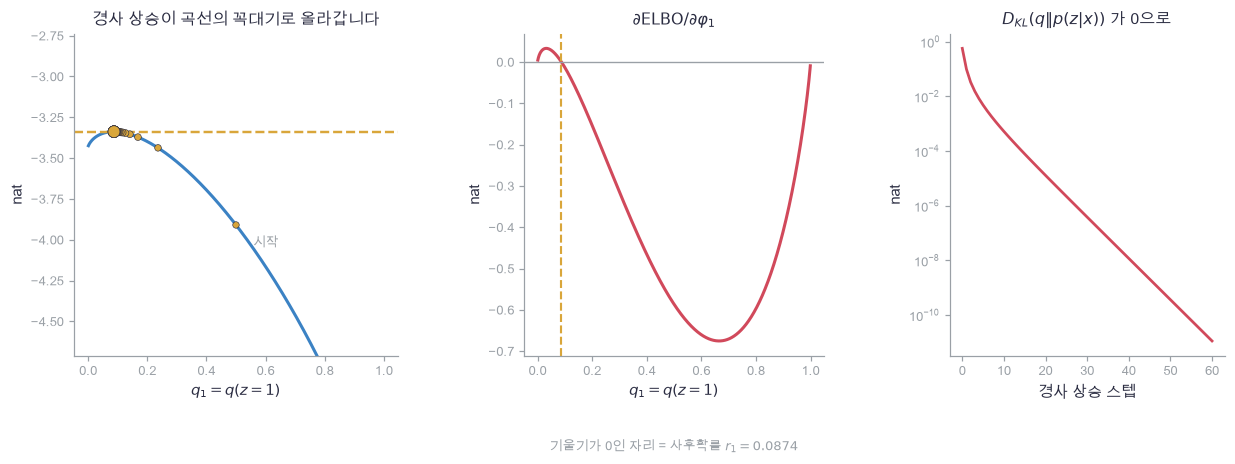

In [26]:
plot_phi_ascent(q1_grid, ascent_curve, ascent_grad_curve, ascent_q1, ascent_elbo, ascent_kl,
                ascent_evidence, float(ascent_r[1]))

🔍 **확인** · 왼쪽에서 금색 점들이 경사 상승의 스텝입니다. 점이 커질수록 나중 스텝이고, 곡선을 따라 꼭대기로 올라가 금색 점선(증거 $\log p(-1)=-3.3383$)에 붙습니다. 처음 몇 스텝에서 거의 다 올라가므로 점들이 위쪽에 겹쳐 보입니다.
가운데는 기울기 $\partial\mathrm{ELBO}/\partial\varphi_1$을 $q_1$의 함수로 그린 것입니다. $q_1$이 사후확률보다 작으면 **양수**라 $\varphi_1$을 올리고, 크면 음수라 내립니다. 0을 지나는 자리가 정확히 $r_1(-1)=0.0874$입니다.
오른쪽은 KL을 로그 눈금으로 본 것입니다. $0.5712$에서 시작해 5스텝 만에 $0.005$ 아래, 60스텝 뒤에는 $10^{-11}$까지 내려갑니다. **하한을 올리는 일과 사후확률을 찾는 일이 같은 일**이라는 2절의 말을 그림으로 본 셈입니다.

아래 구현은 위 반복문 안에 흩어져 있던 세 줄을 함수 하나로 묶습니다.

In [27]:
def elbo_gradient_phi(x, phi):
    """logit φ 로 만든 q = softmax(φ) 에서의 ELBO 와 그 φ 기울기.
    ∂ELBO/∂φ_j = q_j [log p(x, z=j) − log q_j − ELBO]. x: (N,), phi: (N, K) → (q: (N, K), elbo: (N,), dphi: (N, K))."""
    # 쓰는 것: softmax_rows (📎 23번 함수 셀) · joint_log_terms (2절)
    q = softmax_rows(phi)                                             # (N, K): 제약이 저절로 지켜지는 추측 분포
    log_joint = joint_log_terms(x)                                    # (N, K): log p(x, z = k)
    elbo = np.sum(q * (log_joint - np.log(q)), axis=1)                # (N,): 지금의 하한
    return q, elbo, q * (log_joint - np.log(q) - elbo[:, None])       # 대괄호가 성분의 몫 − 평균

In [28]:
# 쓰는 것: ascent_x0, ascent_q1, ascent_elbo, ascent_kl, ascent_r, ascent_evidence (4절 계산 셀) · elbo_discrete (2절)
check_phi = np.array([[0.3, -0.7], [1.0, 0.2]])                       # (2, 2): 검산용 logit 두 행
check_phi_x = np.array([0.0, 1.5])                                    # (2,): 서로 다른 관측 두 개
check_q, check_elbo, check_dphi = elbo_gradient_phi(check_phi_x, check_phi)


def phi_scalar():
    """검사기용: 스칼라 L = Σ_n ELBO_n (φ 를 흔들어 중심차분할 대상)."""
    return float(np.sum(elbo_gradient_phi(check_phi_x, check_phi)[1]))


phi_error = rel_error(check_dphi, numerical_gradient(phi_scalar, check_phi))
assert phi_error < 1e-7, "φ 기울기의 상대오차가 1e−7 아래여야 합니다"
assert np.max(np.abs(check_dphi.sum(axis=1))) < 1e-12, "기울기를 성분 축에서 더하면 0 이어야 합니다"
np.testing.assert_allclose(check_elbo, elbo_discrete(check_phi_x, check_q))        # 검산: 2절 함수와 같은 하한
converged_q = np.array([[1 - ascent_q1[-1], ascent_q1[-1]]])                        # (1, 2): 경사 상승이 60스텝 뒤 도착한 q
np.testing.assert_allclose(converged_q, ascent_r[None, :], atol=1e-5)              # 검산: 23번 2절의 책임확률 r(−1) 과 1e−5 안에서 같음
np.testing.assert_allclose(ascent_elbo[-1], ascent_evidence, atol=1e-9)            # 검산: 도착점의 하한 = 증거
assert np.all(np.diff(ascent_kl) <= 1e-15), "경사 상승은 KL 을 스텝마다 늘리지 않아야 합니다"
_, _, dphi_at_posterior = elbo_gradient_phi(np.array([ascent_x0]), np.log(ascent_r)[None, :])
assert np.max(np.abs(dphi_at_posterior)) < 1e-15, "q 가 정확한 사후확률이면 기울기가 정확히 0 이어야 합니다"
print(f"중심차분 상대오차 {phi_error:.2e} · 도착한 q 와 r(−1) 의 최대 차이 {np.max(np.abs(converged_q - ascent_r)):.2e}")
print(f"정확한 사후확률에서의 기울기 최대 크기 {np.max(np.abs(dphi_at_posterior)):.2e}")

중심차분 상대오차 4.95e-10 · 도착한 q 와 r(−1) 의 최대 차이 1.34e-06
정확한 사후확률에서의 기울기 최대 크기 0.00e+00


### ✏️ 연습 4 · 평균보다 큰 성분의 logit을 올린다

결합 로그 항 `log_joint` `(N, K)`, 지금의 `q` `(N, K)`, 그 `elbo` `(N,)`에서 $\partial\mathrm{ELBO}/\partial\varphi_j=q_j[\log p(x,z=j)-\log q_j-\mathrm{ELBO}]$를 한 줄로 만드세요. `elbo`는 `(N,)`이므로 `(N, K)`와 빼려면 축 하나를 세워야 합니다. 검사는 손계산 두 값과 `elbo_gradient_phi`로 합니다.

In [29]:
def exercise_phi_gradient(log_joint, q, elbo):
    """연습 4: ELBO 의 logit 기울기. log_joint: (N, K), q: (N, K), elbo: (N,) → dphi: (N, K)."""
    assert log_joint.shape == q.shape, "log_joint 와 q 는 같은 (N, K) 여야 합니다"
    assert elbo.shape == (len(q),), "elbo 는 관측마다 숫자 하나인 (N,) 여야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: dphi = q ⊙ [log p(x, z=j) − log q − ELBO]  (모양 (N, K))
    ### 힌트: 4절 수식입니다. elbo[:, None] 로 (N, 1) 을 만들어야 (N, K) 에서 뺄 수 있습니다.
    raise NotImplementedError
    return dphi

In [30]:
def check_phi_gradient(candidate):
    """x = 0, q = (0.5, 0.5) 손계산과 사후확률에서의 0, 그리고 4절 elbo_gradient_phi 로 검사합니다."""
    # 쓰는 것: joint_log_terms (2절) · elbo_gradient_phi (4절) · posterior_at0 (2절 계산 셀)
    example_log_joint = joint_log_terms(np.array([0.0]))              # (1, 2): x = 0 의 결합 로그 항
    example_q = np.array([[0.5, 0.5]])                                # (1, 2)
    example_elbo = np.sum(example_q * (example_log_joint - np.log(example_q)), axis=1)   # (1,): 2절의 ELBO
    np.testing.assert_allclose(example_elbo, [-5.659542], atol=1e-6)  # 검산: 2절 손계산 ELBO 를 검사기가 맞게 만들었는지
    actual = candidate(example_log_joint, example_q, example_elbo)
    assert actual.shape == (1, 2), f"dphi 의 모양은 (N, K) = (1, 2) 여야 하는데 {actual.shape} 입니다"
    np.testing.assert_allclose(actual, [[-1.538538, 1.538538]], atol=1e-5)   # 검산: 손계산 0.5 × (로그 항 + 0.693147 + 5.659542)
    np.testing.assert_allclose(actual.sum(axis=1), [0.0], atol=1e-12)        # 검산: 성분 축의 합은 0
    posterior_q = posterior_at0[None, :]                              # (1, 2): 정확한 사후확률
    posterior_elbo = np.sum(posterior_q * (example_log_joint - np.log(posterior_q)), axis=1)
    np.testing.assert_allclose(candidate(example_log_joint, posterior_q, posterior_elbo), 0.0, atol=1e-12)   # 검산: 사후확률에서 0
    q_ref, elbo_ref, dphi_ref = elbo_gradient_phi(np.array([0.0, 1.5]), np.array([[0.3, -0.7], [1.0, 0.2]]))
    np.testing.assert_allclose(candidate(joint_log_terms(np.array([0.0, 1.5])), q_ref, elbo_ref), dphi_ref)   # 검산: 4절 함수와 같음
    print("logit 기울기: 손계산·elbo_gradient_phi 와 일치합니다.")

run_check(check_phi_gradient, exercise_phi_gradient, hint="dphi = q * (log_joint - np.log(q) - elbo[:, None])")

☐ exercise_phi_gradient: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: dphi = q * (log_joint - np.log(q) - elbo[:, None])


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
dphi = q * (log_joint - np.log(q) - elbo[:, None])
```

</details>

## 🔑 5. 잠재가 연속이면: Gaussian $q$와 재매개화 샘플

**이 절에서 가져갈 것:** $q=\mathcal N(\mu,\sigma^2)$로 두면 사전분포와의 KL은 12번 5절의 **닫힌식**이고, 재구성 항은 $z=\mu+\sigma\epsilon$ 샘플의 평균으로 추정합니다. 미분은 $\epsilon$을 고정한 채 경로를 따라 흐르며(12번 6절), 이렇게 올린 하한은 정확한 사후확률에서 최대가 됩니다.

지금까지는 잠재가 0 아니면 1이라 두 항을 다 더할 수 있었습니다. 이제 잠재가 실수 하나인 모형을 봅니다.
$z\sim\mathcal N(0,1)$을 뽑고 $x=az+s\,\epsilon_{\text{obs}}$로 관측을 만듭니다($a=2$, $s=0.5$). 합이 적분이 되었으니 2절의 "$\sum_k$"를 그대로 코드로 옮길 수는 없습니다.
대신 $q$를 Gaussian 하나로 제한하고, 3절의 두 항 중 **KL은 닫힌식으로, 재구성 항은 샘플 평균으로** 계산합니다.

> **용어**
>
> - **선형 Gaussian 모형**: $p(z)=\mathcal N(0,1)$, $p(x\mid z)=\mathcal N(az,s^2)$. 사후확률도 Gaussian이라 정답을 손으로 쓸 수 있는 드문 모형입니다.
> - **재매개화(reparameterization)**: "$q$에서 $z$를 뽑는다"를 "표준정규 $\epsilon$을 뽑아 $\mu+\sigma\epsilon$으로 옮긴다"로 다시 쓰는 것(12번 6절). 미분이 $\mu,\sigma$를 지나가게 합니다.
> - **pathwise 미분**: 잡음 $\epsilon$을 고정해 놓고 그 경로를 따라 미분하는 것. $\epsilon$을 바꾸지 않으므로 보통의 연쇄법칙이 그대로 통합니다.

로그 분산 $\ell=\log\sigma^2$을 파라미터로 씁니다($\sigma=e^{\ell/2}>0$이 저절로 지켜집니다). 3절의 두 항은

$$\mathrm{ELBO}(x;\mu,\ell)=\underbrace{\mathbb E_{q}\big[\log\mathcal N(x;az,s^2)\big]}_{\text{재구성 항}}
-\underbrace{\tfrac12\big(\mu^2+e^{\ell}-1-\ell\big)}_{D_{KL}(q\,\|\,\mathcal N(0,1))}.$$

KL은 12번 5절 닫힌식에서 $p$를 표준정규로 둔 특수형입니다. 재구성 항은 $\epsilon_k\sim\mathcal N(0,1)$ $K$개를 뽑아

$$z_k=\mu+e^{\ell/2}\epsilon_k,\qquad \widehat{\text{재구성}}=\frac1K\sum_{k=0}^{K-1}\log\mathcal N(x;az_k,s^2),\qquad \epsilon:(N,K)\to z:(N,K)\to(N,).$$

이 절의 $K$와 $k$는 2–4절의 성분 수·성분 번호가 아니라 **샘플 수와 샘플 번호**입니다. 축 0이 관측, 축 1이 샘플입니다.

$\epsilon$을 고정하면 $\partial z_k/\partial\mu=1$, $\partial z_k/\partial\ell=e^{\ell/2}\epsilon_k/2$이므로, $d_k=\partial\log\mathcal N(x;az_k,s^2)/\partial z_k=a(x-az_k)/s^2$을 $K$로 나눈 값에서

$$\frac{\partial\,\mathrm{ELBO}}{\partial\mu}=\sum_k\frac{d_k}{K}-\mu,\qquad
\frac{\partial\,\mathrm{ELBO}}{\partial\ell}=\sum_k\frac{d_k}{K}\cdot\frac{e^{\ell/2}\epsilon_k}{2}-\frac{e^{\ell}-1}{2}.$$

이 모형의 **정답**도 적어 둡니다. 사후확률은 $p(z\mid x)=\mathcal N(m,v)$이고

$$v=\frac{1}{1+a^2/s^2},\qquad m=v\,\frac{a\,x}{s^2},\qquad \log p(x)=\log\mathcal N(x;0,a^2+s^2).$$

$a=2,s=0.5$이면 $v=1/17=0.058824$, $x=1$에서 $m=8/17=0.470588$, $\sigma^*=\sqrt v=0.242536$이고 $\log p(1)=-1.760045$입니다.
재구성 항도 적분이 닫힌식이라($\mathbb E_q[(x-az)^2]=(x-a\mu)^2+a^2e^{\ell}$) 정확한 ELBO를 쓸 수 있고, 샘플 추정이 맞는지 재는 자로 씁니다.

In [31]:
# 쓰는 것: LG_A, LG_S (📎 모형 상수 셀)
lg_x = 1.0                                                            # 이 절에서 보는 관측 한 점
lg_v = 1.0 / (1.0 + LG_A ** 2 / LG_S ** 2)                            # 사후확률 분산 v (닫힌식)
lg_m = lg_v * LG_A * lg_x / LG_S ** 2                                 # 사후확률 평균 m (닫힌식)
lg_evidence = -0.5 * (np.log(2 * np.pi * (LG_A ** 2 + LG_S ** 2)) + lg_x ** 2 / (LG_A ** 2 + LG_S ** 2))   # log p(x)
lg_z = np.linspace(-3.4, 3.4, 501)                                    # (501,): 밀도를 그릴 z 격자
lg_prior_density = np.exp(-0.5 * lg_z ** 2) / np.sqrt(2 * np.pi)      # (501,): p(z) = N(0, 1)
lg_posterior_density = np.exp(-0.5 * (lg_z - lg_m) ** 2 / lg_v) / np.sqrt(2 * np.pi * lg_v)   # (501,): 정확한 사후확률
lg_start_mu, lg_start_logvar = 0.0, 0.0                               # 학습을 시작할 자리 q = N(0, 1)
lg_start_density = np.exp(-0.5 * (lg_z - lg_start_mu) ** 2 / np.exp(lg_start_logvar)) / np.sqrt(2 * np.pi * np.exp(lg_start_logvar))
print(f"v = {lg_v:.6f} · m = {lg_m:.6f} · σ* = {np.sqrt(lg_v):.6f} · log p(x) = {lg_evidence:.6f}")

v = 0.058824 · m = 0.470588 · σ* = 0.242536 · log p(x) = -1.760045

In [32]:
# 쓰는 것: lg_x, lg_v, lg_m (5절 계산 셀) · LG_A, LG_S (📎 모형 상수 셀)
# 그림에 쓸 격자. 위 수식의 정확한 ELBO(재구성 항 닫힌식 − KL 닫힌식)를 그대로 옮긴 것입니다.
lg_mu_grid = np.linspace(-0.4, 1.4, 361)                              # (361,): μ 축
lg_logvar_grid = np.linspace(-6.0, 1.2, 361)                          # (361,): ℓ = log σ² 축
lg_recon_mu = -0.5 * np.log(2 * np.pi * LG_S ** 2) - ((lg_x - LG_A * lg_mu_grid) ** 2 + LG_A ** 2 * lg_v) / (2 * LG_S ** 2)
lg_elbo_mu = lg_recon_mu - 0.5 * (lg_mu_grid ** 2 + lg_v - 1.0 - np.log(lg_v))   # (361,): σ 를 정답에 두고 μ 만 움직임
lg_recon_logvar = -0.5 * np.log(2 * np.pi * LG_S ** 2) - ((lg_x - LG_A * lg_m) ** 2 + LG_A ** 2 * np.exp(lg_logvar_grid)) / (2 * LG_S ** 2)
lg_elbo_logvar = lg_recon_logvar - 0.5 * (lg_m ** 2 + np.exp(lg_logvar_grid) - 1.0 - lg_logvar_grid)   # (361,): μ 를 정답에 두고 ℓ 만 움직임
print(f"μ 축의 꼭대기 {lg_mu_grid[lg_elbo_mu.argmax()]:.4f} (m = {lg_m:.4f})")
print(f"ℓ 축의 꼭대기 {lg_logvar_grid[lg_elbo_logvar.argmax()]:.4f} (log v = {np.log(lg_v):.4f})")

μ 축의 꼭대기 0.4700 (m = 0.4706)
ℓ 축의 꼭대기 -2.8400 (log v = -2.8332)


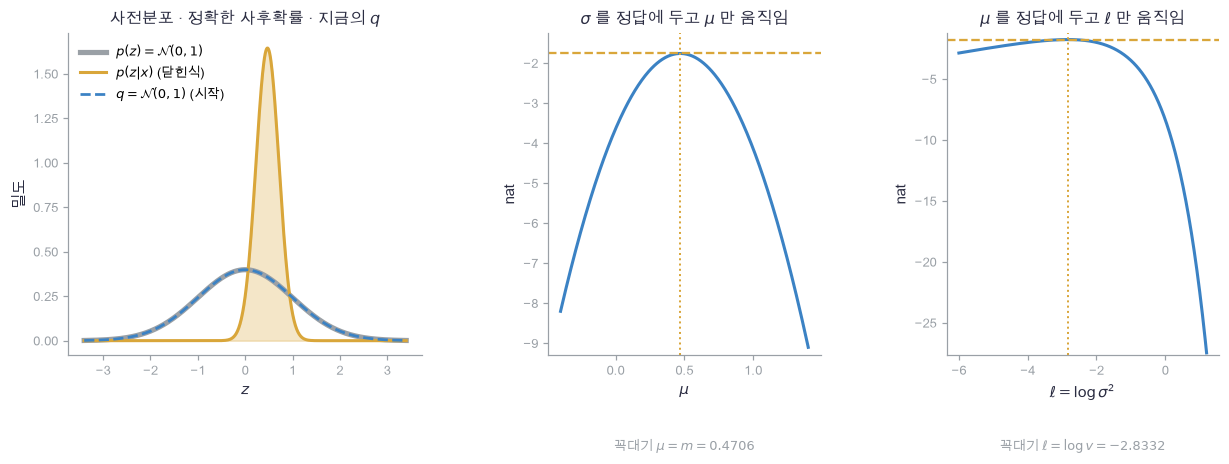

In [33]:
plot_gaussian_elbo_landscape(lg_z, lg_prior_density, lg_posterior_density, lg_start_density,
                             "$q = \\mathcal{N}(0, 1)$ (시작)", lg_mu_grid, lg_elbo_mu,
                             lg_logvar_grid, lg_elbo_logvar, lg_evidence, lg_m, float(np.log(lg_v)))

🔍 **확인** · 왼쪽에서 회색이 사전분포 $\mathcal N(0,1)$, 금색이 정확한 사후확률 $\mathcal N(0.4706,\,0.0588)$입니다. 관측 $x=1$을 보고 나면 잠재가 있을 만한 자리가 **크게 좁아집니다**. 파란 점선은 학습을 시작할 $q=\mathcal N(0,1)$이라 아직 사전분포와 같습니다.
가운데는 $\sigma$를 정답에 고정하고 $\mu$만 움직인 정확한 ELBO입니다. 꼭대기가 $\mu=m=0.4706$이고 그 높이가 금색 점선, 곧 $\log p(1)=-1.7600$입니다.
오른쪽은 $\mu$를 정답에 고정하고 $\ell$만 움직인 것입니다. 꼭대기가 $\ell=\log v=-2.8332$입니다. $\ell$이 너무 작으면(너무 좁으면) KL의 $-\ell$ 항이 커지고, 너무 크면 재구성 항의 $a^2e^{\ell}$이 커집니다.
**두 축 모두에서 꼭대기가 닫힌식 사후확률이고 그 높이가 증거입니다.** 2절의 항등식이 연속 잠재에서도 그대로입니다.

아래 구현은 사후확률·증거의 닫힌식, 표준정규 기준 KL, 정확한 ELBO, 그리고 샘플로 추정한 ELBO와 그 기울기를 차례로 둡니다.

In [34]:
def linear_posterior(x):
    """선형 Gaussian 모형의 정확한 사후확률 N(m, v): v = 1/(1 + a²/s²), m = v a x / s².
    x: 숫자 또는 (N,) → (m: 같은 모양, v: 숫자)."""
    # 쓰는 것: LG_A, LG_S (📎 모형 상수 셀)
    v = 1.0 / (1.0 + LG_A ** 2 / LG_S ** 2)
    return v * LG_A * np.asarray(x, dtype=float) / LG_S ** 2, v


def linear_evidence(x):
    """같은 모형의 증거 log p(x) = log N(x; 0, a² + s²). x = a z + s ε 이므로 분산이 더해집니다.
    x: 숫자 또는 (N,) → 같은 모양."""
    total = LG_A ** 2 + LG_S ** 2
    return -0.5 * (np.log(2 * np.pi * total) + np.asarray(x, dtype=float) ** 2 / total)


def gaussian_kl_standard(mu, logvar):
    """D_KL(N(μ, e^ℓ) ‖ N(0, 1)) = ½(μ² + e^ℓ − 1 − ℓ). 12번 5절 닫힌식의 표준정규 판입니다.
    mu, logvar: (N,) → (N,)."""
    return 0.5 * (mu ** 2 + np.exp(logvar) - 1.0 - logvar)

In [35]:
def elbo_gaussian_exact(x, mu, logvar):
    """선형 Gaussian 모형의 정확한 ELBO. 재구성 항의 적분이 닫힌식이라 샘플 없이 계산됩니다.
    E_q[(x − a z)²] = (x − a μ)² + a² e^ℓ. x, mu, logvar: (N,) → (elbo: (N,), recon: (N,), kl: (N,))."""
    # 쓰는 것: LG_A, LG_S (📎 모형 상수 셀) · gaussian_kl_standard (5절)
    recon = -0.5 * np.log(2 * np.pi * LG_S ** 2) - ((x - LG_A * mu) ** 2 + LG_A ** 2 * np.exp(logvar)) / (2 * LG_S ** 2)
    kl = gaussian_kl_standard(mu, logvar)
    return recon - kl, recon, kl

In [36]:
def elbo_gaussian(x, mu, logvar, eps):
    """재매개화 샘플로 추정한 ELBO 와 ε 을 고정한 pathwise 기울기.
    z = μ + e^{ℓ/2} ε, 재구성 항은 샘플 평균, KL 은 닫힌식입니다.
    x, mu, logvar: (N,), eps: (N, K) → (elbo, recon, kl, dmu, dlogvar) 모두 (N,)."""
    # 쓰는 것: LG_A, LG_S (📎 모형 상수 셀) · gaussian_kl_standard (5절)
    sigma = np.exp(0.5 * logvar)                                      # (N,): σ = e^{ℓ/2}
    z = mu[:, None] + sigma[:, None] * eps                            # (N, K): 재매개화 샘플 (12번 6절)
    log_likelihood = -0.5 * np.log(2 * np.pi * LG_S ** 2) - (x[:, None] - LG_A * z) ** 2 / (2 * LG_S ** 2)
    recon = log_likelihood.mean(axis=1)                               # (N,): 샘플 축 평균
    kl = gaussian_kl_standard(mu, logvar)                             # (N,): 닫힌식이라 샘플이 필요 없음
    dz = LG_A * (x[:, None] - LG_A * z) / LG_S ** 2 / eps.shape[1]    # (N, K): ∂재구성/∂z_k 를 K 로 나눈 것
    dmu = dz.sum(axis=1) - mu                                         # (N,): ∂z/∂μ = 1, KL 쪽은 −μ
    dlogvar = np.sum(dz * eps * sigma[:, None] * 0.5, axis=1) - 0.5 * (np.exp(logvar) - 1.0)
    return recon - kl, recon, kl, dmu, dlogvar

In [37]:
# 쓰는 것: lg_x, lg_m, lg_v, lg_evidence, lg_mu_grid, lg_elbo_mu (5절 계산 셀)
probe_x, probe_mu, probe_logvar = np.array([lg_x]), np.array([0.3]), np.array([-2.0])   # 추정을 시험할 자리
probe_exact = elbo_gaussian_exact(probe_x, probe_mu, probe_logvar)[0]
probe_eps = np.random.default_rng(2405).normal(size=(1, 200000))      # (1, 200000): 큰 표본으로 추정
probe_estimate = elbo_gaussian(probe_x, probe_mu, probe_logvar, probe_eps)[0]
assert abs(float(probe_estimate[0] - probe_exact[0])) < 0.02, "20만 개 샘플 추정이 닫힌식과 0.02 안에서 같아야 합니다"
np.testing.assert_allclose(linear_posterior(lg_x)[0], lg_m)           # 검산: 5절 계산 셀의 m
np.testing.assert_allclose(linear_posterior(lg_x)[1], lg_v)           # 검산: 5절 계산 셀의 v
np.testing.assert_allclose(linear_evidence(np.array([lg_x])), [lg_evidence])   # 검산: 5절 계산 셀의 log p(x)
best_elbo = elbo_gaussian_exact(probe_x, np.array([lg_m]), np.array([np.log(lg_v)]))[0]
np.testing.assert_allclose(best_elbo, [lg_evidence], atol=1e-12)      # 검산: 최적 q 에서 하한 = 증거 (2절 항등식의 연속판)
grid_logvar = np.full(len(lg_mu_grid), np.log(lg_v))                  # (361,): σ 를 정답에 고정
np.testing.assert_allclose(elbo_gaussian_exact(np.full(len(lg_mu_grid), lg_x), lg_mu_grid, grid_logvar)[0], lg_elbo_mu)   # 검산: 그림에 쓴 μ 축 곡선 = 5절 구현의 배열
assert np.all(elbo_gaussian_exact(probe_x, lg_mu_grid, np.log(lg_v))[0] <= lg_evidence + 1e-12), "격자 전체에서 하한은 증거를 넘지 않아야 합니다"
print(f"닫힌식 ELBO {probe_exact[0]:.6f} · 20만 샘플 추정 {probe_estimate[0]:.6f} · 차이 {probe_estimate[0] - probe_exact[0]:+.6f}")
print(f"최적 q 의 ELBO {best_elbo[0]:.6f} · 증거 {lg_evidence:.6f}")

닫힌식 ELBO -2.241141 · 20만 샘플 추정 -2.236377 · 차이 +0.004764
최적 q 의 ELBO -1.760045 · 증거 -1.760045


In [38]:
# 쓰는 것: gaussian_kl_standard, elbo_gaussian, elbo_gaussian_exact (5절)
grad_x = np.array([1.0, -0.6])                                        # (2,): 관측 두 개
grad_mu = np.array([0.2, -0.3])                                       # (2,)
grad_logvar = np.array([-0.5, 0.4])                                   # (2,)
grad_eps = np.random.default_rng(2406).normal(size=(2, 7))            # (2, 7): 고정한 잡음 (중심차분 내내 그대로)
_, _, _, grad_dmu, grad_dlogvar = elbo_gaussian(grad_x, grad_mu, grad_logvar, grad_eps)


def gaussian_elbo_scalar():
    """검사기용: 같은 ε 을 고정한 ELBO 의 합 (μ 나 ℓ 을 흔들어 중심차분할 대상)."""
    return float(np.sum(elbo_gaussian(grad_x, grad_mu, grad_logvar, grad_eps)[0]))


gaussian_errors = [rel_error(grad_dmu, numerical_gradient(gaussian_elbo_scalar, grad_mu)),
                   rel_error(grad_dlogvar, numerical_gradient(gaussian_elbo_scalar, grad_logvar))]
assert max(gaussian_errors) < 1e-7, "재매개화 기울기 두 개의 상대오차가 1e−7 아래여야 합니다"
np.testing.assert_allclose(gaussian_kl_standard(np.zeros(1), np.zeros(1)), [0.0], atol=1e-15)   # 검산: q = p(z) 면 KL 은 0
np.testing.assert_allclose(gaussian_kl_standard(np.array([1.0]), np.array([0.0])), [0.5])       # 검산: 손계산 ½μ² = 0.5
big_eps = np.random.default_rng(2407).normal(size=(2, 1000000))
big_recon = elbo_gaussian(grad_x, grad_mu, grad_logvar, big_eps)[1]    # (2,): 100 만 샘플로 추정한 재구성 항
np.testing.assert_allclose(big_recon, elbo_gaussian_exact(grad_x, grad_mu, grad_logvar)[1], atol=0.05)   # 검산: 재구성 항의 샘플 평균 = 닫힌식 (σ 가 넓어 흔들림이 큼)
print("재매개화 기울기 상대오차: dμ", f"{gaussian_errors[0]:.2e}", "· dℓ", f"{gaussian_errors[1]:.2e}")

재매개화 기울기 상대오차: dμ 7.38e-11 · dℓ 2.56e-10


### 🔍 샘플 수 $K$를 바꾸면 추정이 얼마나 흔들리나

$K$개의 $\epsilon$은 매번 새로 뽑으므로 추정값도 매번 다릅니다. 같은 $(\mu,\ell)$에서 추정을 4,000번 되풀이해 흩어짐을 재 봅니다.
서로 독립인 항 $K$개의 평균이므로 표준편차는 $1/\sqrt K$로 줄어들어야 합니다(01b 2절의 미니배치 잡음과 같은 이유). **기댓값은 $K$와 무관하게 정확한 값입니다.**

In [39]:
# 쓰는 것: probe_exact (5절 검산 셀) · elbo_gaussian (5절)
spread_k = [1, 4, 16, 64]                                             # 비교할 샘플 수
spread_rng = np.random.default_rng(2408)
spread_repeats = 4000                                                 # 같은 (μ, ℓ) 에서 되풀이할 횟수
spread_x = np.full(spread_repeats, 1.0)                               # (4000,): 같은 관측
spread_mu = np.full(spread_repeats, 0.3)                              # (4000,): 같은 μ
spread_logvar = np.full(spread_repeats, -2.0)                         # (4000,): 같은 ℓ
spread_estimates, spread_stds, spread_means = [], [], []
for k in spread_k:
    values = elbo_gaussian(spread_x, spread_mu, spread_logvar, spread_rng.normal(size=(spread_repeats, k)))[0]
    spread_estimates.append(values[:300])                             # 그림에 뿌릴 300 개만
    spread_stds.append(float(values.std()))
    spread_means.append(float(values.mean()))                     # 그림 왼쪽 패널의 금색 눈금
    print(f"K = {k:3d}: 평균 {values.mean():9.5f} (정확한 값 {probe_exact[0]:.5f}) · 표준편차 {values.std():.5f}")
spread_ratio = np.array(spread_stds)[0] / np.array(spread_stds)       # 표준편차가 몇 배 줄었나
assert np.max(np.abs(spread_ratio / np.sqrt(spread_k) - 1.0)) < 0.08, "표준편차 비가 √K 에서 8% 넘게 벗어나면 안 됩니다"
spread_reference = spread_stds[0] / np.sqrt(np.array(spread_k, dtype=float) / spread_k[0])   # (4,): 그림에 그릴 σ_1/√K 기준선
print("표준편차 비 σ_1/σ_K =", spread_ratio.round(3), "· √K =", np.sqrt(spread_k).round(3))

K =   1: 평균  -2.29420 (정확한 값 -2.24114) · 표준편차 2.04145
K =   4: 평균  -2.27568 (정확한 값 -2.24114) · 표준편차 0.99323
K =  16: 평균  -2.23547 (정확한 값 -2.24114) · 표준편차 0.48224
K =  64: 평균  -2.23749 (정확한 값 -2.24114) · 표준편차 0.24629
표준편차 비 σ_1/σ_K = [1.    2.055 4.233 8.289] · √K = [1. 2. 4. 8.]


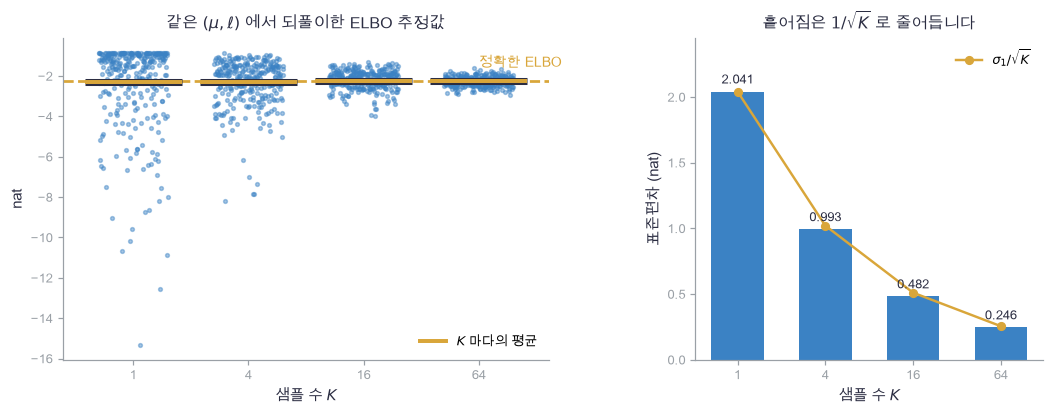

In [40]:
plot_elbo_sample_spread(spread_k, spread_estimates, spread_means, spread_stds,
                        float(probe_exact[0]), spread_reference)

🔍 **확인** · 왼쪽에서 점 무리가 $K$를 키울수록 금색 점선(정확한 ELBO $-2.2411$)에 좁게 모입니다. $K$가 작으면 추정값의 분포가 **아래로 긴 꼬리**를 끌어서, 점 무리의 눈에 보이는 가운데는 점선보다 위에 있습니다($K=1$에서 4,000번 추정의 중앙값은 $-1.51$). 그래도 열마다 금색 눈금으로 찍은 **평균**(4,000번 전체의 평균)은 $K$와 상관없이 점선 위에 있습니다(위 셀의 $-2.294$ / $-2.276$ / $-2.235$ / $-2.237$). 편향이 없다는 말은 점이 모여 보이는 자리가 아니라 **평균**에 대한 말입니다(4,000번의 평균 자체도 표본이라 소수 둘째 자리에서 조금 흔들립니다).
오른쪽 막대가 표준편차이고 금색 선이 $\sigma_1/\sqrt K$ 기준선입니다. $K$를 4배로 하면 흩어짐이 절반이 됩니다.
25번 VAE에서 $K=1$(샘플 하나)만 쓰고도 학습이 되는 이유가 여기 있습니다. 추정이 흔들려도 **평균이 맞으면** 여러 스텝에 걸쳐 잡음이 상쇄됩니다. 대신 한 스텝의 방향은 믿을 것이 못 됩니다.

### 🔍 재매개화 기울기로 $q$를 직접 학습시키기

이제 $\mu$와 $\ell$을 0에서 시작해 위 기울기로 600스텝 올려 봅니다. 스텝마다 $\epsilon$을 $K=64$개 새로 뽑고, 학습률은 0.05에서 0으로 곧게 줄입니다(잡음이 남아 있어 끝에서 보폭을 줄여야 자리를 잡습니다).
학습용 작은 문제이므로 실제 모델의 성능으로 읽지 마세요. 여기서 보려는 것은 하나입니다. **샘플로만 계산한 기울기가 닫힌식 사후확률로 데려가는가.**

In [41]:
# 쓰는 것: lg_x, lg_m, lg_v, lg_evidence, lg_start_mu, lg_start_logvar, lg_z (5절 계산 셀) · elbo_gaussian, elbo_gaussian_exact (5절)
train_rng = np.random.default_rng(2401)
train_steps, train_k, train_lr0 = 600, 64, 0.05
train_mu, train_logvar = np.array([lg_start_mu]), np.array([lg_start_logvar])
train_history, train_mu_path, train_sigma_path = [], [], []
for step in range(train_steps + 1):
    train_history.append(float(elbo_gaussian_exact(np.array([lg_x]), train_mu, train_logvar)[0][0]))   # 갱신 전의 자리를 기록
    train_mu_path.append(float(train_mu[0]))
    train_sigma_path.append(float(np.exp(0.5 * train_logvar[0])))
    if step == train_steps:
        break
    eps_now = train_rng.normal(size=(1, train_k))                     # (1, 64): 이번 스텝의 새 잡음
    _, _, _, step_dmu, step_dlogvar = elbo_gaussian(np.array([lg_x]), train_mu, train_logvar, eps_now)
    learning_rate = train_lr0 * (1 - step / train_steps)              # 곧게 줄어드는 보폭
    train_mu = train_mu + learning_rate * step_dmu                    # 경사 상승 (하한을 키우는 방향)
    train_logvar = train_logvar + learning_rate * step_dlogvar
train_sigma = float(np.exp(0.5 * train_logvar[0]))
train_density = np.exp(-0.5 * (lg_z - train_mu[0]) ** 2 / train_sigma ** 2) / np.sqrt(2 * np.pi * train_sigma ** 2)
assert abs(train_mu[0] - lg_m) < 1e-2, "학습된 μ 가 닫힌식 m 과 0.01 안에서 같아야 합니다"
assert abs(train_sigma - np.sqrt(lg_v)) < 1e-2, "학습된 σ 가 닫힌식 √v 와 0.01 안에서 같아야 합니다"
assert abs(train_history[-1] - lg_evidence) < 2e-2, "끝의 정확한 ELBO 가 증거와 0.02 안에서 같아야 합니다"
print(f"학습된 μ {train_mu[0]:.6f} (닫힌식 {lg_m:.6f}) · σ {train_sigma:.6f} (닫힌식 {np.sqrt(lg_v):.6f})")
print(f"시작 ELBO {train_history[0]:.6f} → 끝 ELBO {train_history[-1]:.6f} · 증거 {lg_evidence:.6f}")

학습된 μ 0.468343 (닫힌식 0.470588) · σ 0.243389 (닫힌식 0.242536)
시작 ELBO -10.225791 → 끝 ELBO -1.760100 · 증거 -1.760045


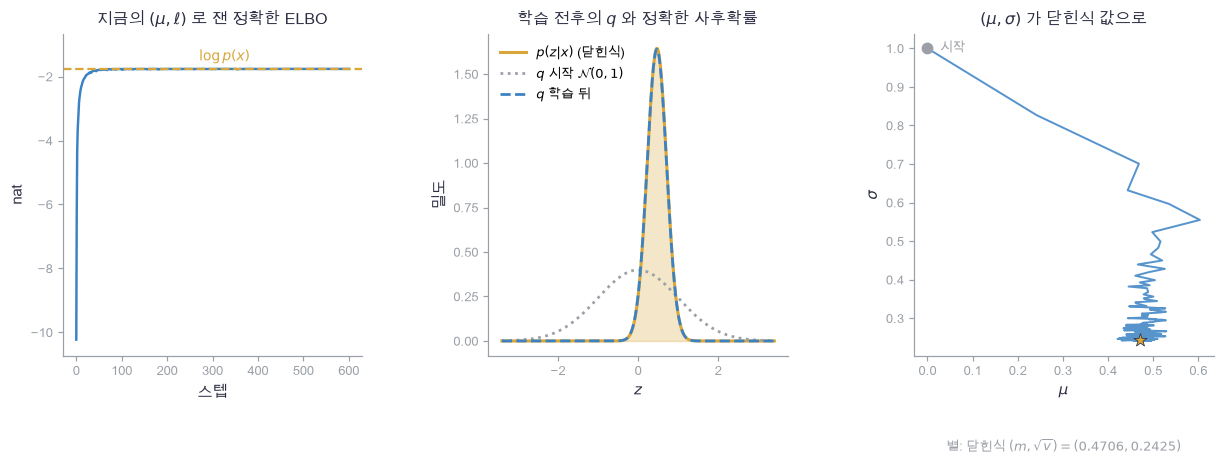

In [42]:
plot_gaussian_q_learning(train_history, lg_evidence, lg_z, lg_posterior_density,
                         [lg_start_density, train_density], ["$q$ 시작 $\\mathcal{N}(0, 1)$", "$q$ 학습 뒤"],
                         train_mu_path, train_sigma_path, lg_m, float(np.sqrt(lg_v)))

🔍 **확인** · 왼쪽에서 정확한 ELBO가 $-10.23$에서 시작해 금색 점선 $\log p(1)=-1.7600$ 바로 아래까지 올라갑니다. 선이 매끄럽지 않고 잘게 떨리는 것은 스텝마다 $\epsilon$이 새로 뽑히기 때문입니다.
가운데에서 회색 점선(시작 $q$)이 금색 사후확률과 전혀 다르다가, 파란 점선(학습된 $q$)은 금색 봉우리와 거의 겹칩니다. 오른쪽은 $(\mu,\sigma)$가 지나간 길이고 별이 닫힌식 $(m,\sqrt v)=(0.4706,\,0.2426)$입니다.
샘플 64개짜리 잡음 섞인 기울기만 썼는데도 **닫힌식 정답의 0.01 안**에 들어왔습니다. 남은 오차는 마지막까지 남아 있는 추정 잡음입니다.

### ✏️ 연습 5 · 재매개화 샘플로 재구성 항 추정하기

관측 `x` `(N,)`, 평균 `mu` `(N,)`, 로그 분산 `logvar` `(N,)`, 고정한 잡음 `eps` `(N, K)`에서 샘플 `z` `(N, K)`와 재구성 항 추정값 `recon` `(N,)`을 만드는 두 줄을 채우세요. 샘플마다 $\log\mathcal N(x;az,s^2)$을 계산한 뒤 **샘플 축에서 평균**냅니다. 검사는 $\epsilon=(1,-1)$인 손계산과 5절의 `elbo_gaussian`으로 합니다.

In [43]:
def exercise_sample_recon(x, mu, logvar, eps):
    """연습 5: 재매개화 샘플과 그 샘플로 추정한 재구성 항. x, mu, logvar: (N,), eps: (N, K) → (z: (N, K), recon: (N,))."""
    assert x.shape == mu.shape == logvar.shape, "x, mu, logvar 는 모두 같은 (N,) 여야 합니다"
    assert eps.shape[0] == len(x), "eps 는 관측마다 샘플 K 개인 (N, K) 여야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: z = μ + e^{ℓ/2} ε (모양 (N, K)) 와, 샘플마다의 log N(x; a z, s²) 를 샘플 축에서 평균낸 recon (모양 (N,))
    ### 힌트: 5절 elbo_gaussian 의 z 줄과 recon 줄입니다. (N,) 를 (N, K) 와 맞추려면 [:, None] 로 세웁니다. 평균은 axis=1.
    raise NotImplementedError
    return z, recon

In [44]:
def check_sample_recon(candidate):
    """ε = (1, −1) 손계산과 5절 elbo_gaussian·elbo_gaussian_exact 로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: elbo_gaussian, elbo_gaussian_exact (5절) · LG_A, LG_S (📎 모형 상수 셀)
    example_x = np.array([1.0])                                       # (1,)
    example_mu = np.array([0.0])                                      # (1,)
    example_logvar = np.array([0.0])                                  # (1,): σ = 1
    example_eps = np.array([[1.0, -1.0]])                             # (1, 2): 평균 0, 제곱 평균 1 인 잡음 두 개
    z, recon = candidate(example_x, example_mu, example_logvar, example_eps)
    assert z.shape == (1, 2), f"z 의 모양은 (N, K) = (1, 2) 여야 하는데 {z.shape} 입니다"
    np.testing.assert_allclose(z, [[1.0, -1.0]])                      # 검산: μ = 0, σ = 1 이면 z = ε
    np.testing.assert_allclose(recon, [-10.2257913526], atol=1e-8)    # 검산: 손계산 ½[(−0.225791 − 2) + (−0.225791 − 18)]
    np.testing.assert_allclose(recon, elbo_gaussian_exact(example_x, example_mu, example_logvar)[1])   # 검산: 닫힌식 재구성 항과 같음
    ref_eps = np.random.default_rng(77).normal(size=(2, 5))
    ref_x, ref_mu, ref_logvar = np.array([1.0, -0.6]), np.array([0.2, -0.3]), np.array([-0.5, 0.4])
    ref_recon = elbo_gaussian(ref_x, ref_mu, ref_logvar, ref_eps)[1]  # (2,): 5절 구현이 내는 재구성 항
    np.testing.assert_allclose(candidate(ref_x, ref_mu, ref_logvar, ref_eps)[1], ref_recon)   # 검산: 5절 elbo_gaussian 의 recon
    print("재매개화 샘플과 재구성 항: 손계산과 일치합니다.")

run_check(check_sample_recon, exercise_sample_recon, hint="z = mu[:, None] + np.exp(0.5 * logvar)[:, None] * eps · recon = np.mean(-0.5 * np.log(2 * np.pi * LG_S ** 2) - (x[:, None] - LG_A * z) ** 2 / (2 * LG_S ** 2), axis=1)")

☐ exercise_sample_recon: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: z = mu[:, None] + np.exp(0.5 * logvar)[:, None] * eps · recon = np.mean(-0.5 * np.log(2 * np.pi * LG_S ** 2) - (x[:, None] - LG_A * z) ** 2 / (2 * LG_S ** 2), axis=1)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
z = mu[:, None] + np.exp(0.5 * logvar)[:, None] * eps
recon = np.mean(-0.5 * np.log(2 * np.pi * LG_S ** 2) - (x[:, None] - LG_A * z) ** 2 / (2 * LG_S ** 2), axis=1)
```

</details>

## ✏️ 6. 직접 채워서 확인합니다

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.**
`raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요.
아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

### 연습 A · 성분을 하나씩 돌며 더한 ELBO (2절)

절 연습 2는 같은 계산을 배열 한 줄로 했습니다. 이번에는 성분마다 결합 로그 항을 직접 만들어 `total`에 더합니다. 반복문과 결합 로그 항 줄은 써 두었으니 **더하는 한 줄**을 채우세요.

In [45]:
def exercise_elbo_enumerate(x, q, pi, mu, sigma):
    """연습 A: 성분을 하나씩 돌며 더한 ELBO. x: (N,), q: (N, K) 행 합 1, pi·mu·sigma: (K,) → (N,)."""
    assert q.shape[1] == len(pi), "q 의 열 수는 성분 수 K 와 같아야 합니다"
    assert np.all(q > 0), "이 연습은 모든 성분의 확률이 양수인 q 만 다룹니다"
    total = np.zeros(len(x))                                          # (N,): 0 에서 시작해 성분마다 더합니다
    for k in range(len(pi)):
        log_joint = np.log(pi[k]) - 0.5 * (np.log(2 * np.pi * sigma[k] ** 2) + (x - mu[k]) ** 2 / sigma[k] ** 2)   # (N,): log p(x, z = k)
        ### 이 주석 아래에 다음을 구현하세요.
        ### 구현할 내용: 성분 k 의 몫 q[:, k] × (log p(x, z=k) − log q[:, k]) 를 total 에 더하기
        ### 힌트: 2절 수식 Σ_k q_k [log p(x, z=k) − log q_k] 를 성분마다 나눠 더하는 것입니다. total += ... 한 줄입니다.
        raise NotImplementedError
    return total

In [46]:
def check_elbo_enumerate(candidate):
    """2절 손계산, 격자 전체의 elbo_discrete, 그리고 성분 3 개 혼합으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: elbo_discrete (2절) · grid_x, grid_q (2절 계산 셀) · MIX_PI, MIX_MU, MIX_SIGMA (📎 혼합 상수 셀)
    actual = candidate(np.array([0.0]), np.array([[0.5, 0.5]]), MIX_PI, MIX_MU, MIX_SIGMA)
    assert actual.shape == (1,), f"ELBO 의 모양은 (N,) = (1,) 여야 하는데 {actual.shape} 입니다"
    np.testing.assert_allclose(actual, [-5.659542], atol=1e-6)        # 검산: 2절 손계산
    np.testing.assert_allclose(candidate(grid_x, grid_q, MIX_PI, MIX_MU, MIX_SIGMA), elbo_discrete(grid_x, grid_q))   # 검산: 격자 999 개
    three_pi = np.array([0.25, 0.35, 0.40])                           # (3,): 성분 3 개로 늘려도 같은 반복문
    three_q = np.array([[0.2, 0.3, 0.5]])                             # (1, 3)
    three_value = candidate(np.array([0.0]), three_q, three_pi, np.array([-3.0, 0.0, 3.0]), np.array([0.6, 0.8, 0.7]))
    assert three_value.shape == (1,), "성분 수가 3 이어도 결과는 관측마다 숫자 하나여야 합니다"
    np.testing.assert_allclose(three_value, [-7.684027], atol=1e-6)   # 검산: 성분 3 개의 가중합 (같은 반복문이 K = 3 에서도 맞아야 함)
    print("열거한 ELBO: 손계산·elbo_discrete 와 일치합니다.")

run_check(check_elbo_enumerate, exercise_elbo_enumerate, hint="total += q[:, k] * (log_joint - np.log(q[:, k]))")

☐ exercise_elbo_enumerate: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: total += q[:, k] * (log_joint - np.log(q[:, k]))


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
total += q[:, k] * (log_joint - np.log(q[:, k]))
```

</details>

### ✏️ 연습 B · 사후확률과 얼마나 멀어졌나 (2절)

추측 분포 `q` `(N, K)`와 정확한 사후확률 `r` `(N, K)`에서 $D_{KL}(q\,\|\,p(z\mid x))=\sum_k q_k\log(q_k/r_k)$를 한 줄로 만드세요. 절 연습 3의 KL과 식은 같고 **기준 분포만 다릅니다**. 검사는 2절 손계산 $2.386051$과 항등식 `증거 − ELBO = KL`로 합니다.

In [47]:
def exercise_posterior_gap(q, r):
    """연습 B: 사후확률과의 KL. q: (N, K) 행 합 1, r: (N, K) 행 합 1 → (N,)."""
    assert q.shape == r.shape, "q 와 r 는 같은 (N, K) 여야 합니다"
    assert np.all(q > 0), "이 연습은 모든 성분의 확률이 양수인 q 만 다룹니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: kl = Σ_k q_k log(q_k / r_k)  (모양 (N,))
    ### 힌트: 2절 수식입니다. 절 연습 3 과 같은 모양이고 나누는 상대만 π 에서 r 로 바뀝니다.
    raise NotImplementedError
    return kl

In [48]:
def check_posterior_gap(candidate):
    """2절 손계산과 항등식 증거 − ELBO = KL 로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: mix_responsibility (📎 23번 함수 셀) · evidence, elbo_discrete, posterior_kl (2절) · grid_x, grid_q (2절 계산 셀)
    example_q = np.array([[0.5, 0.5]])                                # (1, 2)
    example_r = mix_responsibility(np.array([0.0]))                   # (1, 2): 정확한 사후확률 r(0)
    actual = candidate(example_q, example_r)
    assert actual.shape == (1,), f"KL 의 모양은 (N,) = (1,) 여야 하는데 {actual.shape} 입니다"
    np.testing.assert_allclose(actual, [2.386051], atol=1e-6)         # 검산: 2절 손계산
    np.testing.assert_allclose(candidate(example_r, example_r), [0.0], atol=1e-15)   # 검산: q = r 이면 0
    grid_kl = candidate(grid_q, mix_responsibility(grid_x))
    np.testing.assert_allclose(grid_kl, evidence(grid_x) - elbo_discrete(grid_x, grid_q), atol=1e-10)   # 검산: 증거 − ELBO = KL
    np.testing.assert_allclose(grid_kl, posterior_kl(grid_x, grid_q))                                    # 검산: 2절 posterior_kl 과 같음
    print("사후확률과의 KL: 손계산·항등식과 일치합니다.")

run_check(check_posterior_gap, exercise_posterior_gap, hint="kl = np.sum(q * np.log(q / r), axis=1)")

☐ exercise_posterior_gap: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: kl = np.sum(q * np.log(q / r), axis=1)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
kl = np.sum(q * np.log(q / r), axis=1)
```

</details>

### ✏️ 연습 C · 표준정규 기준의 대각 KL (5절)

잠재가 $D$차원이면 좌표마다 항을 만들어 더합니다. `mu`, `logvar` `(N, D)`에서 $D_{KL}\big(\mathcal N(\mu,\mathrm{diag}\,e^{\ell})\,\|\,\mathcal N(0,I)\big)=\tfrac12\sum_j(\mu_j^2+e^{\ell_j}-1-\ell_j)$를 한 줄로 만드세요. 12번 5절의 일반 닫힌식에서 $p$를 표준정규로 둔 특수형이고, 25번 VAE가 쓰는 바로 그 항입니다. 검사는 손계산 세 경우와 5절 `gaussian_kl_standard`로 합니다.

In [49]:
def exercise_standard_kl(mu, logvar):
    """연습 C: 표준정규 기준의 대각 Gaussian KL. mu, logvar: (N, D) → (N,)."""
    assert mu.shape == logvar.shape, "mu 와 logvar 는 같은 (N, D) 여야 합니다"
    assert mu.ndim == 2, "이 연습은 좌표 축이 있는 (N, D) 배열만 다룹니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: kl = ½ Σ_j (μ_j² + e^{ℓ_j} − 1 − ℓ_j)  (좌표 축에서 더해 모양 (N,))
    ### 힌트: 5절 수식의 좌표별 판입니다. 분산은 np.exp(logvar) 이고 더하는 축은 axis=1 입니다.
    raise NotImplementedError
    return kl

In [50]:
def check_standard_kl(candidate):
    """μ = 0, ℓ = 0 (0), μ = 1 (½), ℓ = 1 (½(e−2)) 손계산과 5절 gaussian_kl_standard 로 검사합니다."""
    # 쓰는 것: gaussian_kl_standard (5절)
    example = np.array([[0.0, 0.0], [1.0, 0.0], [0.0, 0.0]])          # (3, 2): 세 경우의 μ
    example_logvar = np.array([[0.0, 0.0], [0.0, 0.0], [0.0, 1.0]])   # (3, 2): 세 경우의 ℓ
    actual = candidate(example, example_logvar)
    assert actual.shape == (3,), f"KL 의 모양은 (N,) = (3,) 여야 하는데 {actual.shape} 입니다"
    np.testing.assert_allclose(actual[0], 0.0, atol=1e-15)            # 검산: q = N(0, I) 면 0
    np.testing.assert_allclose(actual[1], 0.5)                        # 검산: 손계산 ½μ² = ½
    np.testing.assert_allclose(actual[2], 0.5 * (np.e - 2.0))         # 검산: 손계산 ½(e^1 − 1 − 1)
    one_d_mu = np.array([[0.3], [-1.2]])                              # (2, 1): 좌표가 하나면 5절 함수와 같아야 함
    one_d_logvar = np.array([[-2.0], [0.7]])
    np.testing.assert_allclose(candidate(one_d_mu, one_d_logvar), gaussian_kl_standard(one_d_mu[:, 0], one_d_logvar[:, 0]))   # 검산: 5절 함수
    assert np.all(candidate(np.random.default_rng(24).normal(size=(50, 4)), np.random.default_rng(25).normal(size=(50, 4))) >= 0), "KL 은 언제나 0 이상이어야 합니다"
    print("표준정규 기준의 대각 KL: 손계산·gaussian_kl_standard 와 일치합니다.")

run_check(check_standard_kl, exercise_standard_kl, hint="kl = 0.5 * np.sum(mu ** 2 + np.exp(logvar) - 1.0 - logvar, axis=1)")

☐ exercise_standard_kl: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: kl = 0.5 * np.sum(mu ** 2 + np.exp(logvar) - 1.0 - logvar, axis=1)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
kl = 0.5 * np.sum(mu ** 2 + np.exp(logvar) - 1.0 - logvar, axis=1)
```

</details>

### ✏️ 연습 D · 샘플을 지나 $\mu$로 흐르는 기울기 (5절)

관측 `x` `(N,)`, 재매개화 샘플 `z` `(N, K)`, 평균 `mu` `(N,)`에서 $\partial\mathrm{ELBO}/\partial\mu=\frac1K\sum_k\frac{a(x-az_k)}{s^2}-\mu$를 한 줄로 만드세요. 앞이 재구성 항에서 온 몫(샘플 축 평균), 뒤가 KL에서 온 $-\mu$입니다. 검사는 $x=1$, $\mu=0$, $\sigma=1$, $\epsilon=(1,-1)$에서 손계산 $8$이 나오는지와, 5절 `elbo_gaussian`의 `dmu`와 같은지 봅니다.

In [51]:
def exercise_elbo_dmu(x, z, mu):
    """연습 D: ε 을 고정한 ELBO 의 μ 기울기. x, mu: (N,), z: (N, K) 재매개화 샘플 → dmu: (N,)."""
    assert x.shape == mu.shape, "x 와 mu 는 같은 (N,) 여야 합니다"
    assert z.shape[0] == len(x), "z 는 관측마다 샘플 K 개인 (N, K) 여야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: dmu = (샘플마다의 a(x − a z_k)/s² 를 샘플 축에서 평균낸 값) − μ   (모양 (N,))
    ### 힌트: 5절 수식입니다. ∂z_k/∂μ = 1 이라 재구성 쪽 기울기가 그대로 지나가고, KL 쪽은 −μ 입니다. 평균은 axis=1.
    raise NotImplementedError
    return dmu

In [52]:
def check_elbo_dmu(candidate):
    """ε = (1, −1) 손계산 8 과 5절 elbo_gaussian 의 dmu 로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: elbo_gaussian (5절) · LG_A, LG_S (📎 모형 상수 셀)
    example_x = np.array([1.0])                                       # (1,)
    example_z = np.array([[1.0, -1.0]])                               # (1, 2): μ = 0, σ = 1, ε = (1, −1) 의 샘플
    example_mu = np.array([0.0])                                      # (1,)
    actual = candidate(example_x, example_z, example_mu)
    assert actual.shape == (1,), f"dmu 의 모양은 (N,) = (1,) 여야 하는데 {actual.shape} 입니다"
    np.testing.assert_allclose(actual, [8.0])                         # 검산: 손계산 ½(2(1−2)/0.25 + 2(1+2)/0.25) − 0 = ½(−8 + 24)
    np.testing.assert_allclose(candidate(example_x, example_z, np.array([3.0])), [5.0])   # 검산: μ 가 3 이면 KL 쪽에서 3 을 뺌
    ref_x, ref_mu, ref_logvar = np.array([1.0, -0.6]), np.array([0.2, -0.3]), np.array([-0.5, 0.4])
    ref_eps = np.random.default_rng(78).normal(size=(2, 5))
    ref_z = ref_mu[:, None] + np.exp(0.5 * ref_logvar)[:, None] * ref_eps
    np.testing.assert_allclose(candidate(ref_x, ref_z, ref_mu), elbo_gaussian(ref_x, ref_mu, ref_logvar, ref_eps)[3])   # 검산: 5절 dmu
    print("μ 로 흐르는 기울기: 손계산·elbo_gaussian 과 일치합니다.")

run_check(check_elbo_dmu, exercise_elbo_dmu, hint="dmu = np.mean(LG_A * (x[:, None] - LG_A * z) / LG_S ** 2, axis=1) - mu")

☐ exercise_elbo_dmu: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: dmu = np.mean(LG_A * (x[:, None] - LG_A * z) / LG_S ** 2, axis=1) - mu


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
dmu = np.mean(LG_A * (x[:, None] - LG_A * z) / LG_S ** 2, axis=1) - mu
```

</details>

### 🔍 완성 예제 · $a$와 $s$를 바꾸면 사후확률이 얼마나 좁아지나

5절의 학습 루프는 $a$와 $s$를 건드리지 않았습니다. 이번에는 같은 코드로 모형 세 개를 학습시킵니다.

- **기본** $a=2$, $s=0.5$: 관측이 잠재를 크게 늘려 보여 주고 잡음이 작아 사후확률이 아주 좁습니다.
- **잡음이 큰 관측** $a=2$, $s=1.5$: 관측이 흐릿해 잠재를 잘 알 수 없습니다.
- **기울기가 작은 모형** $a=0.5$, $s=0.5$: 잠재가 관측에 거의 나타나지 않습니다.

사후확률 분산 $v=1/(1+a^2/s^2)$는 $a^2/s^2$가 클수록 작아집니다. 그 값이 관측이 잠재에 대해 주는 정보의 양입니다.
$a^2/s^2$가 0에 가까우면 $v\to1$, 곧 사후확률이 사전분포로 돌아갑니다. 학습된 $q$가 그 닫힌식을 따라가는지 봅니다. 학습용 작은 문제입니다.

In [53]:
def variant_gradients(x, mu, logvar, eps, a, s):
    """완성 예제용: 5절 elbo_gaussian 과 같은 식에서 a, s 만 인자로 받습니다.
    x, mu, logvar: (N,), eps: (N, K), a·s: 숫자 → (dmu: (N,), dlogvar: (N,))."""
    sigma = np.exp(0.5 * logvar)                                      # (N,): σ = e^{ℓ/2}
    z = mu[:, None] + sigma[:, None] * eps                            # (N, K): 재매개화 샘플
    dz = a * (x[:, None] - a * z) / s ** 2 / eps.shape[1]             # (N, K): ∂재구성/∂z_k 를 K 로 나눈 것
    dmu = dz.sum(axis=1) - mu
    return dmu, np.sum(dz * eps * sigma[:, None] * 0.5, axis=1) - 0.5 * (np.exp(logvar) - 1.0)

In [54]:
# 쓰는 것: lg_x, lg_z (5절 계산 셀) · train_steps, train_k, train_lr0 (5절 학습 셀)
variant_settings = [("기본", "기본 $a=2,\\ s=0.5$", 2.0, 0.5),                    # (출력용 이름, 그림 제목, a, s)
                    ("잡음 큰 관측", "잡음 큰 관측 $a=2,\\ s=1.5$", 2.0, 1.5),
                    ("작은 기울기", "작은 기울기 $a=0.5,\\ s=0.5$", 0.5, 0.5)]
variant_panels = []
for name, panel_title, a_value, s_value in variant_settings:
    target_v = 1.0 / (1.0 + a_value ** 2 / s_value ** 2)              # 닫힌식 사후확률 분산
    target_m = target_v * a_value * lg_x / s_value ** 2               # 닫힌식 사후확률 평균
    rng_variant = np.random.default_rng(2410)
    mu_v, logvar_v = np.array([0.0]), np.array([0.0])
    for step in range(train_steps):
        dmu_v, dlogvar_v = variant_gradients(np.array([lg_x]), mu_v, logvar_v, rng_variant.normal(size=(1, train_k)), a_value, s_value)
        rate = train_lr0 * (1 - step / train_steps)
        mu_v = mu_v + rate * dmu_v
        logvar_v = logvar_v + rate * dlogvar_v
    sigma_v = float(np.exp(0.5 * logvar_v[0]))
    assert abs(mu_v[0] - target_m) < 1e-2, f"{name}: 학습된 μ 가 닫힌식 m 과 0.01 안에서 같아야 합니다"
    assert abs(sigma_v - np.sqrt(target_v)) < 1e-2, f"{name}: 학습된 σ 가 닫힌식 √v 와 0.01 안에서 같아야 합니다"
    exact = np.exp(-0.5 * (lg_z - target_m) ** 2 / target_v) / np.sqrt(2 * np.pi * target_v)
    learned = np.exp(-0.5 * (lg_z - mu_v[0]) ** 2 / sigma_v ** 2) / np.sqrt(2 * np.pi * sigma_v ** 2)
    variant_panels.append((f"{panel_title}\n$v = {target_v:.4f}$, 학습된 $\\sigma^2 = {sigma_v ** 2:.4f}$", exact, learned))
    print(f"{name}: a²/s² = {a_value ** 2 / s_value ** 2:6.3f} · m {target_m:.4f} → 학습 {mu_v[0]:.4f} · √v {np.sqrt(target_v):.4f} → 학습 {sigma_v:.4f}")

기본: a²/s² = 16.000 · m 0.4706 → 학습 0.4774 · √v 0.2425 → 학습 0.2432
잡음 큰 관측: a²/s² =  1.778 · m 0.3200 → 학습 0.3247 · √v 0.6000 → 학습 0.6007
작은 기울기: a²/s² =  1.000 · m 1.0000 → 학습 1.0035 · √v 0.7071 → 학습 0.7062


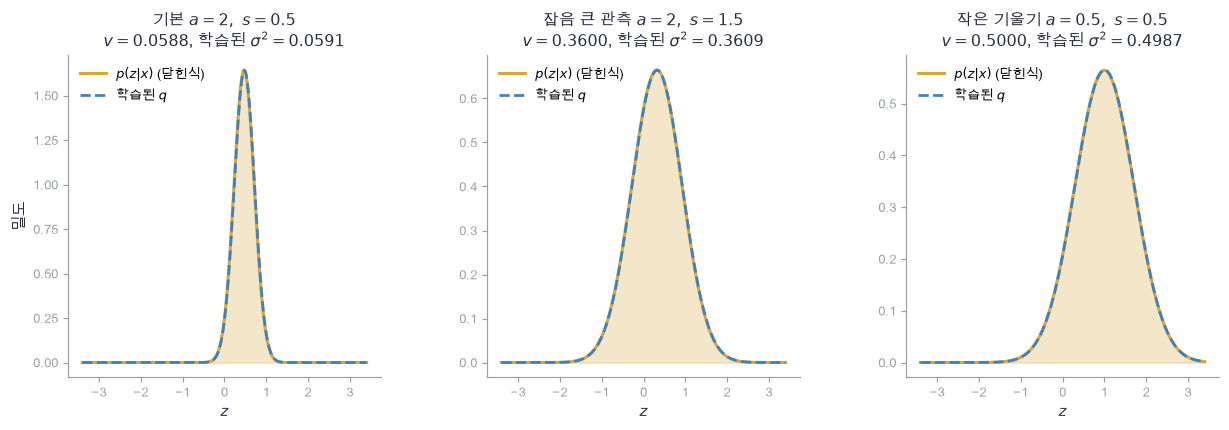

In [55]:
plot_posterior_variants(lg_z, variant_panels)

🔍 **확인** · 세 판 모두 파란 점선(학습된 $q$)이 금색 봉우리(닫힌식 사후확률)를 덮습니다. **같은 기울기 식과 같은 하이퍼파라미터로 세 모형이 모두 맞았습니다.**
왼쪽에서 오른쪽으로 갈수록 $a^2/s^2$가 $16\to1.78\to1$로 줄고 사후확률 분산 $v$가 $0.059\to0.36\to0.5$로 커집니다. 관측이 흐릿하거나 잠재를 별로 실어 나르지 않으면 "보고 나서도 여전히 잘 모르는" 상태가 되고, 그것이 넓은 사후확률입니다.
세 번째 판의 사후확률이 세 판 가운데 가장 넓습니다($v=0.5$로 사전분포 분산의 절반). $a^2/s^2$가 더 작아져 0에 가까워지면 $v\to1$, 곧 사후확률이 사전분포 $\mathcal N(0,1)$과 같아지고, 25번에서 이 극단을 posterior collapse라고 부릅니다.

### 🔍 성분을 3개로 늘려도 같은 항등식

2절의 항등식은 성분 수와 상관없습니다. 성분 3개짜리 혼합에서 추측 분포 200개를 무작위로 만들어 `ELBO + KL = 증거`가 그대로인지 봅니다.

In [56]:
# 쓰는 것: component_log_terms, logsumexp_rows, softmax_rows (📎 23번 함수 셀)
THREE_PI, THREE_MU, THREE_SIGMA = np.array([0.25, 0.35, 0.40]), np.array([-3.0, 0.0, 3.0]), np.array([0.6, 0.8, 0.7])
three_rng = np.random.default_rng(2411)
three_x = three_rng.uniform(-4.0, 4.0, size=200)                      # (200,): 무작위 관측
three_q = three_rng.dirichlet(np.ones(3), size=200)                   # (200, 3): 무작위 추측 분포 (행 합 1)
three_log_joint = component_log_terms(three_x, THREE_PI, THREE_MU, THREE_SIGMA)   # (200, 3): log p(x, z = k)
three_evidence = logsumexp_rows(three_log_joint)                      # (200,): 증거
three_elbo = np.sum(three_q * (three_log_joint - np.log(three_q)), axis=1)        # (200,): 하한
three_kl = np.sum(three_q * np.log(three_q / softmax_rows(three_log_joint)), axis=1)   # (200,): 사후확률과의 KL
three_error = rel_error(three_elbo + three_kl, three_evidence)
assert three_error < 1e-10, "성분 3 개에서도 ELBO + KL 과 증거의 상대오차가 1e−10 아래여야 합니다"
assert np.all(three_elbo <= three_evidence + 1e-12), "성분 3 개에서도 하한은 증거를 넘지 않아야 합니다"
three_posterior = softmax_rows(three_log_joint)                       # (200, 3): 정확한 사후확률
three_best = np.sum(three_posterior * (three_log_joint - np.log(three_posterior)), axis=1)   # (200,): q = 사후확률의 하한
np.testing.assert_allclose(three_best, three_evidence)                # 검산: q = 사후확률이면 하한이 증거와 같음
print(f"성분 3 개 · 관측 200 개: 항등식 상대오차 {three_error:.2e} · 평균 모자란 양 {three_kl.mean():.4f} nat")

성분 3 개 · 관측 200 개: 항등식 상대오차 3.02e-15 · 평균 모자란 양 11.1884 nat


🔍 **확인** · 성분이 3개여도 항등식의 상대오차가 $10^{-10}$ 아래이고, 무작위 $q$ 200개 전부에서 하한이 증거를 넘지 않습니다. $q$를 정확한 사후확률로 두면 모자란 양이 정확히 0입니다.
**"모든 경우를 다 더한다"만 가능하면 성분 수는 상관없습니다.** 문제는 25번처럼 잠재가 연속·다차원이라 더할 수 없을 때이고, 그때는 5절처럼 Gaussian $q$와 샘플 추정을 씁니다.

### ✏️ 준비도 질문 · 다음으로 가기 전, 네 가지를 따로 확인합니다

🔑 표시가 붙은 절의 내용만으로 답할 수 있어야 합니다.

- **설명:** $\log p(x)$를 직접 계산할 수 없을 때 왜 ELBO를 대신 최대화해도 되는지, 그리고 하한을 올리는 일이 왜 사후확률을 찾는 일과 같은지 말할 수 있나요? → 1·2절
- **수식:** 임의의 $q$에 대한 $\log p(x)=\mathrm{ELBO}(q)+D_{KL}(q\,\|\,p(z\mid x))$와 $\mathrm{ELBO}=\mathbb E_q[\log p(x\mid z)]-D_{KL}(q\,\|\,p(z))$를 shape와 함께 쓰고, 두 KL의 기준 분포가 어떻게 다른지 구분할 수 있나요? → 2·3절
- **구현:** 이산 잠재의 ELBO와 두 KL을 각각 한 줄로 쓰고, 연속 잠재에서 KL은 닫힌식·재구성 항은 샘플 평균으로 나누어 계산하는 이유를 설명할 수 있나요? → 3·5절
- **변형:** 성분 수나 $(a, s)$를 바꿔도 항등식이 유지되는 것, 그리고 샘플 수 $K$를 바꾸면 추정의 무엇이 변하고 무엇이 변하지 않는지 말할 수 있나요? → 5절

다음은 [25 VAE](25_vae.ipynb)입니다. 이 노트북에서는 관측 하나마다 $q$의 파라미터($\varphi$ 또는 $(\mu,\ell)$)를 직접 들고 경사 상승을 했습니다.
관측이 5,000장이면 그런 파라미터가 5,000벌 필요합니다. VAE는 그 자리에 신경망(encoder) 하나를 놓아 $x$를 넣으면 $(\mu,\ell)$이 나오게 하고, $p(x\mid z)$도 신경망(decoder)으로 만듭니다. 손실은 3절의 두 항 그대로입니다.

📎 ELBO와 재매개화로 학습하는 방법은 [Kingma·Welling (2013)](https://arxiv.org/abs/1312.6114) 2절에 정리되어 있습니다. 변분 추론 전반의 지도는 [Blei, Kucukelbir, McAuliffe (2017)](https://arxiv.org/abs/1601.00670)에 있고,
"EM도 사실은 하한을 올리는 반복"이라는 관점은 [Neal·Hinton (1998)](https://www.cs.toronto.edu/~radford/ftp/emk.pdf)에 있습니다(23번 4절의 EM이 이 노트북의 ELBO와 만나는 자리입니다). 이 노트북의 예제와 숫자는 설명을 위해 새로 구성한 것입니다.